# Project V1.5 - One Best Model Feature Expansion

`v1.5`의 목적은 `v1` 피처를 버리는 것이 아닙니다.

- `v1`에서 이미 검증된 core feature를 유지합니다.
- `v1.5`에서 새로운 candidate feature를 발굴합니다.
- 이후 `v1 + v1.5` 후보 전체를 기준으로 최선의 단일모델(one best unified model)을 다시 선택합니다.

즉 `v1.5`는 별도의 운영 모델이 아니라,
최종 단일모델을 만들기 위한 피처 확장 및 실험 단계입니다.


## 0. 이번 단계의 합의 사항

### 모델 방향
- 편입 모델 / 편출 모델 / 가중치 모델로 나누지 않고 단일모델에 집중
- 목표는 `v1 + 신규 피처` 전체 후보 중 가장 좋은 단일모델을 선택하는 것

### 문제 정의
- 현재 문제는 binary classification이기도 하지만 ranking 성격도 강함
- top300 후보를 scoring해서 top200 안쪽을 예측하는 구조이므로
  `편입/편출 여부`와 함께 `1~200위 순위 정확도`도 중요함

### v1.5에서 할 일
1. v1 core feature 정리
2. 모델 패키지에 있는 candidate feature 정리
3. 현재 바로 실험 가능한 후보와 새로 생성해야 할 후보 구분
4. rank-aware 평가 관점 추가
5. 최종 단일모델 선택을 위한 실험 순서 정의


In [366]:
from pathlib import Path
import pickle

import pandas as pd

BASE_DIR = Path.cwd()
MODEL_PKG_PATH = BASE_DIR / "data" / "raw" / "model_package.pkl"
MODEL_INPUT_PATH = BASE_DIR / "data" / "incoming" / "auto" / "model_input_2026_H1.csv"

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", 200)

with MODEL_PKG_PATH.open("rb") as f:
    pkg = pickle.load(f)

model_input = pd.read_csv(MODEL_INPUT_PATH) if MODEL_INPUT_PATH.exists() else pd.DataFrame()

print("model_version:", pkg.get("model_version"))
print("model_name:", pkg.get("model_name"))
print("selected feature count:", len(pkg.get("features", [])))
print("model_input rows:", len(model_input))


model_version: v1
model_name: LightGBM
selected feature count: 10
model_input rows: 286


## 1. 현재 v1 단일모델에서 실제로 사용하는 core features

In [367]:
core_features = list(pkg.get("features", []))
feature_group_map = {
    "period_rank": "rank",
    "treasury_ratio": "ownership",
    "sector_relative_rank": "sector",
    "prev_rank": "rank",
    "major_holder_ratio": "ownership",
    "sector_rank": "sector",
    "foreign_change": "foreign",
    "turnover_ratio": "liquidity",
    "sector_member_score": "sector",
    "float_mktcap": "size_float",
}

core_features_df = pd.DataFrame(
    {
        "core_feature": core_features,
        "group": [feature_group_map.get(feature, "other") for feature in core_features],
    }
)
core_features_df


,core_feature,group
0,period_rank,rank
1,treasury_ratio,ownership
2,sector_relative_rank,sector
3,prev_rank,rank
4,major_holder_ratio,ownership
5,sector_rank,sector
6,foreign_change,foreign
7,turnover_ratio,liquidity
8,sector_member_score,sector
9,float_mktcap,size_float


### 해석

현재 `v1` core feature는 대체로 아래 다섯 축으로 해석할 수 있습니다.

- `rank`: `period_rank`, `prev_rank`
- `ownership`: `major_holder_ratio`, `treasury_ratio`
- `sector`: `sector_rank`, `sector_relative_rank`, `sector_member_score`
- `foreign`: `foreign_change`
- `liquidity / float size`: `turnover_ratio`, `float_mktcap`


## 2. 모델 패키지에 있는 전체 feature 후보

In [368]:
feature_sets = {
    "base_features": pkg.get("base_features", []),
    "new_features": pkg.get("new_features", []),
    "enhanced_features": pkg.get("enhanced_features", []),
    "unified_features": pkg.get("unified_features", []),
}

pd.DataFrame(
    [{"set_name": name, "count": len(values)} for name, values in feature_sets.items()]
).sort_values("set_name").reset_index(drop=True)


,set_name,count
0,base_features,44
1,enhanced_features,55
2,new_features,10
3,unified_features,45


In [369]:
feature_catalog_df = pd.DataFrame(
    [
        {"set_name": name, "feature": feature}
        for name, values in feature_sets.items()
        for feature in values
    ]
)
feature_catalog_df.sort_values(["set_name", "feature"]).reset_index(drop=True)


,set_name,feature
0,base_features,avg_exhaustion_rate
1,base_features,avg_foreign_ratio
2,base_features,avg_mktcap
3,base_features,float_rate
4,base_features,float_ratio
5,base_features,foreign_change
6,base_features,gics_sector_enc
7,base_features,is_managed
8,base_features,is_warning
9,base_features,krx_group_enc


## 3. v1에서 아직 선택하지 않은 candidate feature

In [370]:
all_candidates = sorted(set().union(*feature_sets.values()))
unused_candidates = [feature for feature in all_candidates if feature not in core_features]

unused_candidates_df = pd.DataFrame({"unused_candidate_feature": unused_candidates})
unused_candidates_df


,unused_candidate_feature
0,avg_exhaustion_rate
1,avg_foreign_ratio
2,avg_mktcap
3,consecutive_member
4,dist_from_200
5,float_dist_from_200
6,float_mktcap_rank
7,float_rate
8,float_ratio
9,foreign_acceleration


## 4. 지금 바로 실험 가능한 후보 vs 새로 생성해야 할 후보

In [371]:
available_columns = set(model_input.columns) if not model_input.empty else set()

available_candidates = [feature for feature in unused_candidates if feature in available_columns]
need_generation_candidates = [feature for feature in unused_candidates if feature not in available_columns]

candidate_status_df = pd.DataFrame(
    {
        "available_now": pd.Series(available_candidates),
        "need_generation": pd.Series(need_generation_candidates),
    }
)
candidate_status_df


,available_now,need_generation
0,avg_exhaustion_rate,consecutive_member
1,avg_foreign_ratio,dist_from_200
2,avg_mktcap,float_dist_from_200
3,float_rate,float_mktcap_rank
4,last_foreign_ratio,float_ratio
5,prev_was_member,foreign_acceleration
6,NaN,gics_sector_enc
7,NaN,is_managed
8,NaN,is_warning
9,NaN,krx_group_enc


### 지금 바로 붙여볼 수 있는 강한 후보

현재 `model_input_2026_H1.csv`에 이미 존재해서 바로 단일모델 실험에 넣어볼 수 있는 후보들입니다.


In [372]:
instant_candidate_reason_map = {
    "prev_was_member": "직전 구성종목 여부를 직접 반영",
    "avg_foreign_ratio": "기간 평균 외국인 보유 수준",
    "last_foreign_ratio": "최신 외국인 보유 수준",
    "avg_exhaustion_rate": "외국인 투자한도 소진율 평균",
    "avg_mktcap": "평균 시가총액 자체 정보",
    "float_rate": "실제 유동주식비율",
}

instant_candidates_df = pd.DataFrame(
    {
        "candidate": available_candidates,
        "why_it_matters": [instant_candidate_reason_map.get(feature, "추가 해석 필요") for feature in available_candidates],
    }
)
instant_candidates_df


,candidate,why_it_matters
0,avg_exhaustion_rate,외국인 투자한도 소진율 평균
1,avg_foreign_ratio,기간 평균 외국인 보유 수준
2,avg_mktcap,평균 시가총액 자체 정보
3,float_rate,실제 유동주식비율
4,last_foreign_ratio,최신 외국인 보유 수준
5,prev_was_member,직전 구성종목 여부를 직접 반영


## 5. rank-aware 관점에서 중요한 후보

In [373]:
rank_aware_candidates = pd.DataFrame(
    [
        {
            "candidate": "dist_from_200",
            "type": "rank-aware",
            "reason": "200위 경계와의 거리를 직접 반영",
            "priority": "high",
        },
        {
            "candidate": "float_dist_from_200",
            "type": "rank-aware",
            "reason": "유동시총 기준 200위 경계 거리",
            "priority": "high",
        },
        {
            "candidate": "float_mktcap_rank",
            "type": "rank-aware",
            "reason": "float_mktcap 절대값보다 순위 표현이 더 안정적일 수 있음",
            "priority": "high",
        },
        {
            "candidate": "rank_change",
            "type": "momentum-rank",
            "reason": "전기 대비 순위 변화량",
            "priority": "high",
        },
        {
            "candidate": "mktcap_change",
            "type": "momentum-size",
            "reason": "시가총액 변화량",
            "priority": "medium",
        },
        {
            "candidate": "turnover_change",
            "type": "momentum-liquidity",
            "reason": "회전율 변화량",
            "priority": "medium",
        },
        {
            "candidate": "consecutive_member",
            "type": "membership-history",
            "reason": "연속 구성기간 또는 잔류 안정성 반영",
            "priority": "medium",
        },
        {
            "candidate": "rank_acceleration",
            "type": "momentum-rank",
            "reason": "순위 변화의 2차 변화까지 반영",
            "priority": "medium",
        },
    ]
)
rank_aware_candidates


,candidate,type,reason,priority
0,dist_from_200,rank-aware,200위 경계와의 거리를 직접 반영,high
1,float_dist_from_200,rank-aware,유동시총 기준 200위 경계 거리,high
2,float_mktcap_rank,rank-aware,float_mktcap 절대값보다 순위 표현이 더 안정적일 수 있음,high
3,rank_change,momentum-rank,전기 대비 순위 변화량,high
4,mktcap_change,momentum-size,시가총액 변화량,medium
5,turnover_change,momentum-liquidity,회전율 변화량,medium
6,consecutive_member,membership-history,연속 구성기간 또는 잔류 안정성 반영,medium
7,rank_acceleration,momentum-rank,순위 변화의 2차 변화까지 반영,medium


## 6. 직접 설계할 신규 후보

In [374]:
new_manual_candidates = pd.DataFrame(
    [
        {
            "candidate": "prev_index_member_rank",
            "source": "직접 설계",
            "reason": "전기 KOSPI200 내부에서 몇 위권이었는지 반영",
            "status": "새로 생성 필요",
            "priority": "high",
        },
        {
            "candidate": "listing_age_months",
            "source": "상장일 기반",
            "reason": "신규 상장주와 오래된 종목의 차이를 반영",
            "status": "새로 생성 필요",
            "priority": "medium",
        },
        {
            "candidate": "is_recent_listing",
            "source": "상장일 기반",
            "reason": "최근 상장 여부를 간단한 flag로 반영",
            "status": "새로 생성 필요",
            "priority": "medium",
        },
        {
            "candidate": "listing_age_rank",
            "source": "상장일 기반",
            "reason": "상장 연차를 rank 관점으로 표현",
            "status": "새로 생성 필요",
            "priority": "low",
        },
    ]
)
new_manual_candidates


,candidate,source,reason,status,priority
0,prev_index_member_rank,직접 설계,전기 KOSPI200 내부에서 몇 위권이었는지 반영,새로 생성 필요,high
1,listing_age_months,상장일 기반,신규 상장주와 오래된 종목의 차이를 반영,새로 생성 필요,medium
2,is_recent_listing,상장일 기반,최근 상장 여부를 간단한 flag로 반영,새로 생성 필요,medium
3,listing_age_rank,상장일 기반,상장 연차를 rank 관점으로 표현,새로 생성 필요,low


## 7. v1.5의 구조: Core + Candidate + Final Pool

In [375]:
feature_pool_df = pd.DataFrame(
    [
        {
            "pool": "Core features",
            "description": "v1에서 이미 검증된 핵심 feature",
            "examples": ", ".join(core_features[:6]),
        },
        {
            "pool": "Candidate features",
            "description": "v1.5에서 새로 실험할 추가 후보",
            "examples": "prev_was_member, avg_foreign_ratio, last_foreign_ratio, dist_from_200, rank_change",
        },
        {
            "pool": "Final selected features",
            "description": "Core + Candidate 전체를 두고 다시 고른 최종 단일모델 조합",
            "examples": "실험 후 결정",
        },
    ]
)
feature_pool_df


,pool,description,examples
0,Core features,v1에서 이미 검증된 핵심 feature,"period_rank, treasury_ratio, sector_relative_rank, prev_rank, major_holder_ratio, sector_rank"
1,Candidate features,v1.5에서 새로 실험할 추가 후보,"prev_was_member, avg_foreign_ratio, last_foreign_ratio, dist_from_200, rank_change"
2,Final selected features,Core + Candidate 전체를 두고 다시 고른 최종 단일모델 조합,실험 후 결정


## 8. 목표 y와 평가 관점

In [376]:
target_view_df = pd.DataFrame(
    [
        {
            "관점": "현재 핵심 목표",
            "내용": "top200 포함 여부, strong_in, strong_out 적중",
            "유형": "분류 문제",
        },
        {
            "관점": "추가로 중요한 목표",
            "내용": "1~200위 내부 순위까지 더 정확하게 맞추기",
            "유형": "랭킹 문제",
        },
        {
            "관점": "v1.5 권장 접근",
            "내용": "단일모델은 유지하고 평가 지표에 rank 품질을 추가",
            "유형": "분류 + 랭킹 혼합 평가",
        },
    ]
)
target_view_df


,관점,내용,유형
0,현재 핵심 목표,"top200 포함 여부, strong_in, strong_out 적중",분류 문제
1,추가로 중요한 목표,1~200위 내부 순위까지 더 정확하게 맞추기,랭킹 문제
2,v1.5 권장 접근,단일모델은 유지하고 평가 지표에 rank 품질을 추가,분류 + 랭킹 혼합 평가


### 해석

`v1.5`에서는 feature만 늘리는 것이 아니라 평가 관점도 확장하는 것이 자연스럽습니다.

- 기존: precision, recall, strong_in/out hit
- 추가: 실제 편입 종목 평균 예측순위, 실제 편출 종목 평균 예측순위,
  `pred_rank` vs `actual_rank` 상관, top-k precision, 200위 경계 rank error


## 9. v1.5 실험 우선순위 제안

In [377]:
experiment_plan_df = pd.DataFrame(
    [
        {
            "phase": "1차",
            "goal": "추가 코드 없이 바로 성능 확인",
            "feature_set": "Core + prev_was_member + avg_foreign_ratio + last_foreign_ratio",
            "why": "현재 model_input에 이미 존재",
        },
        {
            "phase": "2차",
            "goal": "시총/유동/소진율 정보 보강",
            "feature_set": "1차 + avg_mktcap + float_rate + avg_exhaustion_rate",
            "why": "이 역시 현재 model_input에 이미 존재",
        },
        {
            "phase": "3차",
            "goal": "ranking 성격 강화",
            "feature_set": "2차 + dist_from_200 + float_dist_from_200 + float_mktcap_rank + rank_change",
            "why": "새 생성 로직이 필요하지만 기대효과가 큼",
        },
        {
            "phase": "4차",
            "goal": "membership/history 추가 반영",
            "feature_set": "3차 + prev_index_member_rank + listing_age_months + is_recent_listing",
            "why": "직접 설계형 신규 feature",
        },
    ]
)
experiment_plan_df


,phase,goal,feature_set,why
0,1차,추가 코드 없이 바로 성능 확인,Core + prev_was_member + avg_foreign_ratio + last_foreign_ratio,현재 model_input에 이미 존재
1,2차,시총/유동/소진율 정보 보강,1차 + avg_mktcap + float_rate + avg_exhaustion_rate,이 역시 현재 model_input에 이미 존재
2,3차,ranking 성격 강화,2차 + dist_from_200 + float_dist_from_200 + float_mktcap_rank + rank_change,새 생성 로직이 필요하지만 기대효과가 큼
3,4차,membership/history 추가 반영,3차 + prev_index_member_rank + listing_age_months + is_recent_listing,직접 설계형 신규 feature


## 10. 이번 단계에서 보류할 것

In [378]:
hold_df = pd.DataFrame(
    [
        {
            "candidate_group": "macro_*",
            "reason": "현재 단계에서는 noise 가능성이 높고 feature 수만 늘릴 수 있음",
        },
        {
            "candidate_group": "is_managed / is_warning",
            "reason": "운영 필터 성격이 강하고 적용 범위가 좁을 수 있음",
        },
        {
            "candidate_group": "분리 모델 / 편입-편출 별도 모델",
            "reason": "이번 단계의 핵심은 단일모델 고도화",
        },
    ]
)
hold_df


,candidate_group,reason
0,macro_*,현재 단계에서는 noise 가능성이 높고 feature 수만 늘릴 수 있음
1,is_managed / is_warning,운영 필터 성격이 강하고 적용 범위가 좁을 수 있음
2,분리 모델 / 편입-편출 별도 모델,이번 단계의 핵심은 단일모델 고도화


## 11. 지금 기준 다음 액션

In [379]:
todo_df = pd.DataFrame(
    [
        {
            "next_step": "Core + 1차 후보 조합 실험 셀 추가",
            "priority": "high",
        },
        {
            "next_step": "rank 품질 평가 지표 섹션 추가",
            "priority": "high",
        },
        {
            "next_step": "dist_from_200, float_dist_from_200, rank_change 생성 로직 추가",
            "priority": "high",
        },
        {
            "next_step": "prev_index_member_rank 정의 및 생성",
            "priority": "medium",
        },
        {
            "next_step": "listing_age_months / is_recent_listing 실험",
            "priority": "medium",
        },
    ]
)
todo_df


,next_step,priority
0,Core + 1차 후보 조합 실험 셀 추가,high
1,rank 품질 평가 지표 섹션 추가,high
2,"dist_from_200, float_dist_from_200, rank_change 생성 로직 추가",high
3,prev_index_member_rank 정의 및 생성,medium
4,listing_age_months / is_recent_listing 실험,medium


## 12. 결론 메모

In [380]:
summary_notes = [
    "v1.5는 v1을 대체하는 버전이 아니라, v1 core feature 위에 candidate feature를 확장하는 단계다.",
    "최종 목표는 core + candidate 전체 후보 중 가장 좋은 단일모델을 다시 고르는 것이다.",
    "지금 바로 붙여볼 수 있는 강한 후보는 prev_was_member, avg_foreign_ratio, last_foreign_ratio, avg_mktcap, float_rate, avg_exhaustion_rate다.",
    "그 다음 핵심 축은 dist_from_200, float_dist_from_200, float_mktcap_rank, rank_change 같은 rank-aware feature다.",
    "평가는 분류 정확도뿐 아니라 순위 품질까지 함께 봐야 한다.",
]
pd.DataFrame({'summary_note': summary_notes})


,summary_note
0,"v1.5는 v1을 대체하는 버전이 아니라, v1 core feature 위에 candidate feature를 확장하는 단계다."
1,최종 목표는 core + candidate 전체 후보 중 가장 좋은 단일모델을 다시 고르는 것이다.
2,"지금 바로 붙여볼 수 있는 강한 후보는 prev_was_member, avg_foreign_ratio, last_foreign_ratio, avg_mktcap, float_rate, avg_exhaustion_rate다."
3,"그 다음 핵심 축은 dist_from_200, float_dist_from_200, float_mktcap_rank, rank_change 같은 rank-aware feature다."
4,평가는 분류 정확도뿐 아니라 순위 품질까지 함께 봐야 한다.


## 13. 지금 바로 가능한 성능 비교: v1 vs 시총순위 baseline

현재 저장소에는 `2025_H1`, `2025_H2` historical prediction 결과가 남아 있으므로,
우선 `v1 단일모델`과 `단순 시총순위 baseline`을 비교할 수 있습니다.

여기서 baseline은 다음처럼 정의합니다.

- 예측 top200: `시총순위`가 1~200인 종목
- baseline 편입 후보: `전기 비멤버`이면서 baseline top200에 들어온 종목
- baseline 편출 후보: `전기 멤버`이면서 baseline top200에서 밀려난 종목

즉 이 비교는 "`v1`이 단순 시총순위 규칙보다 실제 KOSPI200 변경을 더 잘 맞추는가?"를 보는 용도입니다.


In [381]:
import numpy as np
import matplotlib.pyplot as plt

HIST_PRED_DIR = BASE_DIR / "data" / "raw" / "historical_predictions"

COL_CAP_RANK = "시총순위"
COL_ACTUAL_MEMBER = "실제멤버"
COL_ACTUAL_IN = "실제편입"
COL_ACTUAL_OUT = "실제편출"
COL_STRONG_IN = "강력편입"
COL_STRONG_OUT = "강력편출"


In [382]:
def ndcg_at_k(relevance: np.ndarray, scores: np.ndarray, k: int) -> float:
    if len(relevance) == 0:
        return 0.0

    order = np.argsort(scores)[::-1][:k]
    ranked_relevance = relevance[order]
    discounts = 1.0 / np.log2(np.arange(2, len(ranked_relevance) + 2))
    dcg = float(np.sum(ranked_relevance * discounts))

    ideal = np.sort(relevance)[::-1][:k]
    ideal_discounts = 1.0 / np.log2(np.arange(2, len(ideal) + 2))
    idcg = float(np.sum(ideal * ideal_discounts))
    return dcg / idcg if idcg > 0 else 0.0


def summarize_period_comparison(path: Path) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    period = path.stem.replace("kospi200_prediction_", "")
    frame = pd.read_csv(path, encoding="utf-8-sig").copy()
    frame["ticker"] = frame["ticker"].astype(str).str.zfill(6)
    frame = frame.sort_values("pred_rank").reset_index(drop=True)

    actual_members = set(frame.loc[frame[COL_ACTUAL_MEMBER] == 1, "ticker"])
    prev_members = set(frame.loc[frame["prev_member"].fillna(0) == 1, "ticker"])
    actual_in = set(frame.loc[frame[COL_ACTUAL_IN] == 1, "ticker"])
    actual_out = set(frame.loc[frame[COL_ACTUAL_OUT] == 1, "ticker"])

    v1_top200 = set(frame.nsmallest(200, "pred_rank")["ticker"])
    v1_in = set(frame.loc[frame[COL_STRONG_IN] == 1, "ticker"])
    v1_out = set(frame.loc[frame[COL_STRONG_OUT] == 1, "ticker"])

    baseline_top200 = set(frame.nsmallest(200, COL_CAP_RANK)["ticker"])
    baseline_in = baseline_top200 - prev_members
    baseline_out = prev_members - baseline_top200

    metric_rows = []
    for model_name, top200, pred_in, pred_out, score_series in [
        ("v1", v1_top200, v1_in, v1_out, frame["score"].to_numpy()),
        ("cap_rank_baseline", baseline_top200, baseline_in, baseline_out, (-frame[COL_CAP_RANK]).to_numpy()),
    ]:
        in_hit = pred_in & actual_in
        out_hit = pred_out & actual_out

        metric_rows.append(
            {
                "period": period,
                "model": model_name,
                "top200_accuracy": len(top200 & actual_members) / 200 if actual_members else 0.0,
                "in_precision": len(in_hit) / len(pred_in) if pred_in else 0.0,
                "in_recall": len(in_hit) / len(actual_in) if actual_in else 0.0,
                "out_precision": len(out_hit) / len(pred_out) if pred_out else 0.0,
                "out_recall": len(out_hit) / len(actual_out) if actual_out else 0.0,
                "pred_in_count": len(pred_in),
                "actual_in_count": len(actual_in),
                "pred_out_count": len(pred_out),
                "actual_out_count": len(actual_out),
                "ndcg_at_200": ndcg_at_k(frame[COL_ACTUAL_MEMBER].to_numpy(), score_series, 200),
            }
        )

    rank_row = {
        "period": period,
        "actual_member_avg_pred_rank": frame.loc[frame[COL_ACTUAL_MEMBER] == 1, "pred_rank"].mean(),
        "actual_nonmember_avg_pred_rank": frame.loc[frame[COL_ACTUAL_MEMBER] == 0, "pred_rank"].mean(),
        "actual_in_avg_pred_rank": frame.loc[frame[COL_ACTUAL_IN] == 1, "pred_rank"].mean(),
        "actual_out_avg_pred_rank": frame.loc[frame[COL_ACTUAL_OUT] == 1, "pred_rank"].mean(),
        "top20_member_precision": frame.nsmallest(20, "pred_rank")[COL_ACTUAL_MEMBER].mean(),
        "top50_member_precision": frame.nsmallest(50, "pred_rank")[COL_ACTUAL_MEMBER].mean(),
        "top100_member_precision": frame.nsmallest(100, "pred_rank")[COL_ACTUAL_MEMBER].mean(),
        "top200_member_precision": frame.nsmallest(200, "pred_rank")[COL_ACTUAL_MEMBER].mean(),
        "spearman_pred_vs_cap_all": frame["pred_rank"].corr(frame[COL_CAP_RANK], method="spearman"),
        "spearman_pred_vs_cap_members": frame.loc[frame[COL_ACTUAL_MEMBER] == 1, "pred_rank"].corr(
            frame.loc[frame[COL_ACTUAL_MEMBER] == 1, COL_CAP_RANK], method="spearman"
        ),
    }

    detail_rows = []
    false_negative = frame[(frame[COL_ACTUAL_MEMBER] == 1) & (frame["pred_rank"] > 200)].copy()
    false_positive = frame[(frame[COL_ACTUAL_MEMBER] == 0) & (frame["pred_rank"] <= 200)].copy()

    for detail_type, detail_frame in [("false_negative_member", false_negative), ("false_positive_nonmember", false_positive)]:
        for _, row in detail_frame.head(10).iterrows():
            detail_rows.append(
                {
                    "period": period,
                    "detail_type": detail_type,
                    "ticker": row["ticker"],
                    "company": row["company"],
                    "pred_rank": row["pred_rank"],
                    "cap_rank": row[COL_CAP_RANK],
                    "actual_member": row[COL_ACTUAL_MEMBER],
                    "actual_in": row[COL_ACTUAL_IN],
                    "actual_out": row[COL_ACTUAL_OUT],
                }
            )

    return pd.DataFrame(metric_rows), pd.DataFrame([rank_row]), pd.DataFrame(detail_rows)


In [383]:
historical_paths = sorted(HIST_PRED_DIR.glob("kospi200_prediction_*.csv"))

comparison_metric_frames = []
rank_metric_frames = []
error_detail_frames = []

for historical_path in historical_paths:
    metric_df, rank_df, detail_df = summarize_period_comparison(historical_path)
    comparison_metric_frames.append(metric_df)
    rank_metric_frames.append(rank_df)
    error_detail_frames.append(detail_df)

comparison_metrics_df = pd.concat(comparison_metric_frames, ignore_index=True)
rank_quality_df = pd.concat(rank_metric_frames, ignore_index=True)
prediction_error_detail_df = pd.concat(error_detail_frames, ignore_index=True)

comparison_metrics_df


,period,model,top200_accuracy,in_precision,in_recall,out_precision,out_recall,pred_in_count,actual_in_count,pred_out_count,actual_out_count,ndcg_at_200
0,2025_H1,v1,0.935,0.187500,0.750000,0.333333,1.0,16,4,15,5,0.961075
1,2025_H1,cap_rank_baseline,0.880,0.111111,0.750000,0.192308,1.0,27,4,26,5,0.915283
2,2025_H2,v1,0.890,0.173913,0.444444,0.166667,0.5,23,9,18,6,0.925036
3,2025_H2,cap_rank_baseline,0.835,0.142857,0.555556,0.100000,0.5,35,9,30,6,0.879523


In [384]:
comparison_summary_df = (
    comparison_metrics_df.groupby("model")[
        ["top200_accuracy", "in_precision", "in_recall", "out_precision", "out_recall", "ndcg_at_200"]
    ]
    .mean()
    .sort_index()
    .round(4)
)
comparison_summary_df


,top200_accuracy,in_precision,in_recall,out_precision,out_recall,ndcg_at_200
model,,,,,,
cap_rank_baseline,0.8575,0.1270,0.6528,0.1462,0.75,0.8974
v1,0.9125,0.1807,0.5972,0.2500,0.75,0.9431


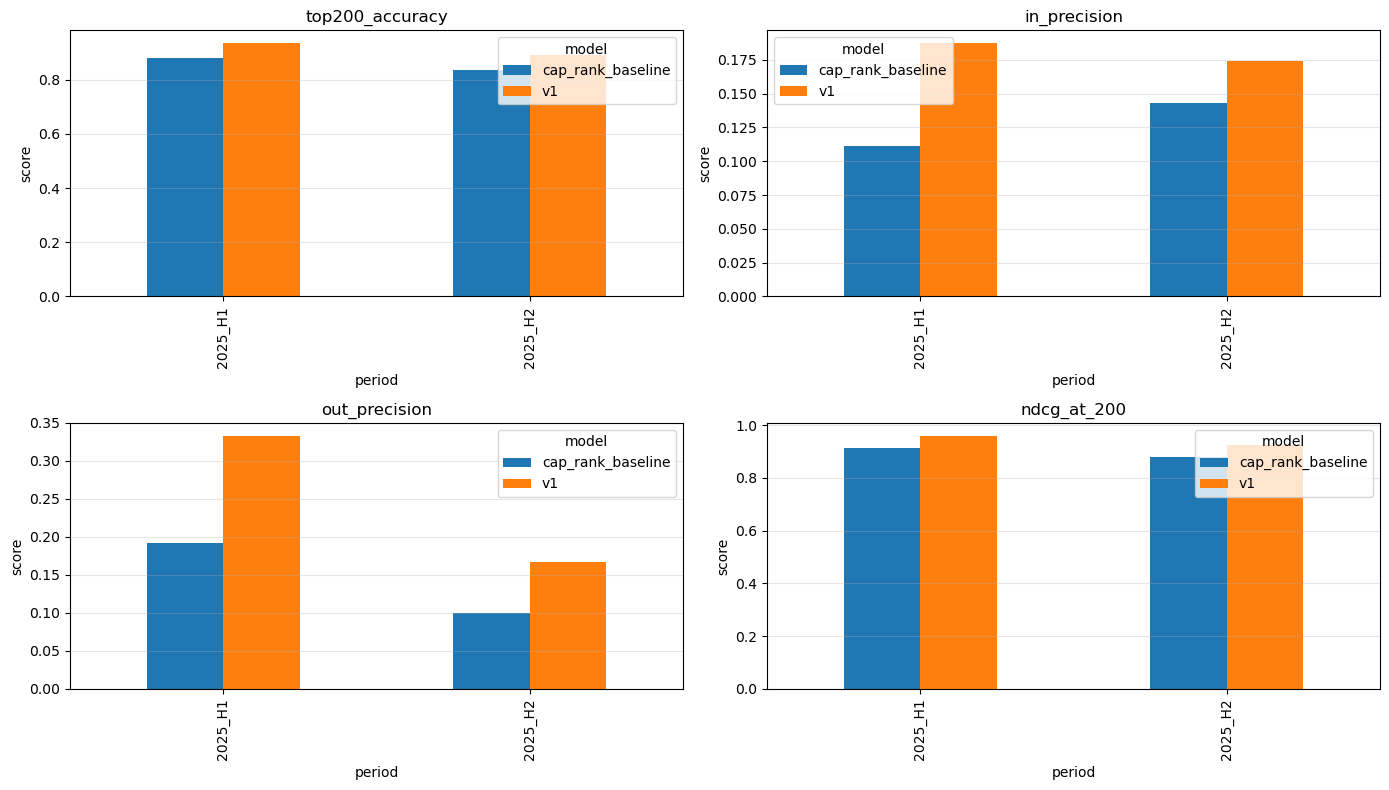

In [385]:
plot_metrics = ["top200_accuracy", "in_precision", "out_precision", "ndcg_at_200"]
plot_df = comparison_metrics_df.pivot(index="period", columns="model", values=plot_metrics)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.ravel()

for ax, metric in zip(axes, plot_metrics):
    metric_slice = comparison_metrics_df.pivot(index="period", columns="model", values=metric)
    metric_slice.plot(kind="bar", ax=ax)
    ax.set_title(metric)
    ax.set_ylabel("score")
    ax.set_xlabel("period")
    ax.grid(axis="y", alpha=0.3)
    ax.legend(title="model")

plt.tight_layout()
plt.show()


## 14. 코스피200 종목 순위도 맞추는지 확인

여기서는 단순히 `top200 안에 들어갔는가`만 보지 않고,
실제 KOSPI200 종목들이 예측 순위 상단에 얼마나 잘 모이는지 확인합니다.

주요 해석 포인트는 아래와 같습니다.

- `actual_member_avg_pred_rank`: 실제 KOSPI200 종목의 평균 예측순위
- `actual_nonmember_avg_pred_rank`: 비멤버 평균 예측순위
- `actual_in_avg_pred_rank`: 실제 편입 종목의 평균 예측순위
- `actual_out_avg_pred_rank`: 실제 편출 종목의 평균 예측순위
- `top20/50/100 member precision`: 예측 상위 구간에서 실제 멤버 비율
- `spearman_pred_vs_cap_*`: 예측순위가 시총순위와 얼마나 비슷한지


In [386]:
rank_quality_df.round(4)


,period,actual_member_avg_pred_rank,actual_nonmember_avg_pred_rank,actual_in_avg_pred_rank,actual_out_avg_pred_rank,top20_member_precision,top50_member_precision,top100_member_precision,top200_member_precision,spearman_pred_vs_cap_all,spearman_pred_vs_cap_members
0,2025_H1,101.5076,229.5844,158.7500,244.8,1.0,1.0,1.0,0.935,0.8908,0.8318
1,2025_H2,105.2487,220.7179,191.7778,191.0,1.0,1.0,1.0,0.890,0.8901,0.8530


In [387]:
rank_quality_summary_df = rank_quality_df.drop(columns=["period"]).mean().to_frame("mean_value").round(4)
rank_quality_summary_df


,mean_value
actual_member_avg_pred_rank,103.3782
actual_nonmember_avg_pred_rank,225.1512
actual_in_avg_pred_rank,175.2639
actual_out_avg_pred_rank,217.9000
top20_member_precision,1.0000
top50_member_precision,1.0000
top100_member_precision,1.0000
top200_member_precision,0.9125
spearman_pred_vs_cap_all,0.8904
spearman_pred_vs_cap_members,0.8424


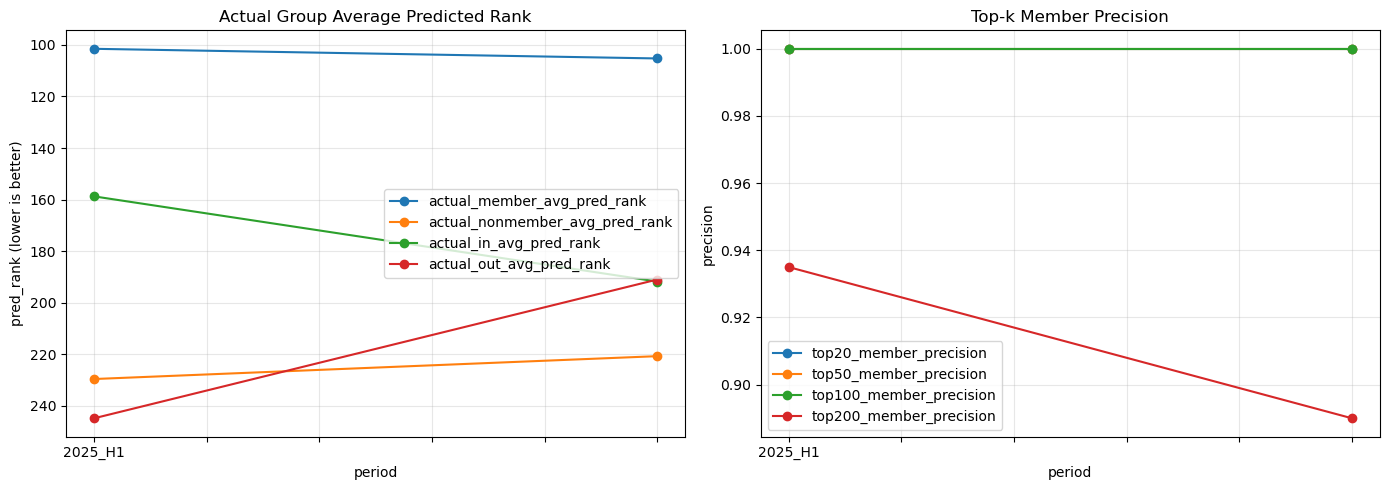

In [388]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

rank_quality_df.plot(
    x="period",
    y=["actual_member_avg_pred_rank", "actual_nonmember_avg_pred_rank", "actual_in_avg_pred_rank", "actual_out_avg_pred_rank"],
    marker="o",
    ax=axes[0],
)
axes[0].invert_yaxis()
axes[0].set_title("Actual Group Average Predicted Rank")
axes[0].set_ylabel("pred_rank (lower is better)")
axes[0].grid(alpha=0.3)

rank_quality_df.plot(
    x="period",
    y=["top20_member_precision", "top50_member_precision", "top100_member_precision", "top200_member_precision"],
    marker="o",
    ax=axes[1],
)
axes[1].set_title("Top-k Member Precision")
axes[1].set_ylabel("precision")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


In [389]:
prediction_error_detail_df.sort_values(["period", "detail_type", "pred_rank"]).reset_index(drop=True)


,period,detail_type,ticker,company,pred_rank,cap_rank,actual_member,actual_in,actual_out
0,2025_H1,false_negative_member,005420,코스모화학,202,257,1,0,0
1,2025_H1,false_negative_member,000210,DL,204,253,1,0,0
2,2025_H1,false_negative_member,005250,녹십자홀딩스,211,254,1,0,0
3,2025_H1,false_negative_member,361610,SK아이이테크놀로지,212,147,1,0,0
4,2025_H1,false_negative_member,008730,율촌화학,218,259,1,0,0
5,2025_H1,false_negative_member,105630,한세실업,234,300,1,0,0
6,2025_H1,false_negative_member,271940,일진하이솔루스,237,277,1,0,0
7,2025_H1,false_negative_member,006650,대한유화,244,278,1,0,0
8,2025_H1,false_negative_member,456040,OCI,246,284,1,1,0
9,2025_H1,false_negative_member,093370,후성,251,293,1,0,0


## 15. v1.5 재학습 비교를 위해 추가로 필요한 것

현재 노트북 기준으로는 `v1`과 `시총순위 baseline` 비교, 그리고 `rank 적합도` 평가는 바로 가능합니다.

하지만 `v1.5 candidate feature 조합`까지 실제로 재학습해서 비교하려면
과거 반기(`2020_H2 ~ 2025_H2`)의 `model_input` 또는 동일 수준의 historical feature snapshot이 추가로 필요합니다.

즉 지금은 아래 두 단계로 보는 게 좋습니다.

1. 지금 바로 가능한 것: `v1 vs baseline` 비교 + rank 품질 확인
2. 다음 단계에서 할 것: historical feature 재구성 후 `v1 core`와 `v1.5 feature set` 재학습 비교


In [390]:
historical_feature_snapshot_df = pd.DataFrame(
    [
        {
            "artifact": "historical prediction csv",
            "path_or_pattern": str(HIST_PRED_DIR / "kospi200_prediction_2025_*.csv"),
            "available": bool(historical_paths),
        },
        {
            "artifact": "historical model_input snapshots",
            "path_or_pattern": str(BASE_DIR / "data" / "incoming" / "auto" / "model_input_202*_H*.csv"),
            "available": len(list((BASE_DIR / "data" / "incoming" / "auto").glob("model_input_202*_H*.csv"))) > 1,
        },
        {
            "artifact": "future current model_input snapshot",
            "path_or_pattern": str(MODEL_INPUT_PATH),
            "available": MODEL_INPUT_PATH.exists(),
        },
    ]
)
historical_feature_snapshot_df


,artifact,path_or_pattern,available
0,historical prediction csv,c:\Users\Admin\Desktop\Project\Next200\Next200_v1\data\raw\historical_predictions\kospi200_prediction_2025_*.csv,True
1,historical model_input snapshots,c:\Users\Admin\Desktop\Project\Next200\Next200_v1\data\incoming\auto\model_input_202*_H*.csv,False
2,future current model_input snapshot,c:\Users\Admin\Desktop\Project\Next200\Next200_v1\data\incoming\auto\model_input_2026_H1.csv,True


## 16. Historical Feature Snapshot 관리 방향: CSV보다 SQL 통합 테이블

`v1.5`부터는 반기별 feature snapshot을 CSV 파일로 흩뿌리기보다,
SQL의 통합 테이블 하나로 관리하는 방향이 더 적합합니다.

핵심 이유는 아래와 같습니다.

- 기간별 학습/검증 셋 분리가 쉬움
- feature set 버전 관리가 쉬움
- `v1`, `v1.5`, `v2` 실험을 같은 구조 안에서 비교 가능
- 종목 단위 history 조회가 쉬움
- 나중에 Streamlit / 분석 노트북 / 학습 스크립트가 같은 원천 데이터를 볼 수 있음


In [391]:
snapshot_design_df = pd.DataFrame(
    [
        {
            "option": "period별 CSV 여러 개",
            "pros": "만들기 단순",
            "cons": "버전 관리와 실험 비교가 불편함",
            "recommendation": "비추천",
        },
        {
            "option": "period별 SQL 테이블 여러 개",
            "pros": "기간별 조회는 직관적",
            "cons": "테이블 수가 많아지고 스키마 변경 관리가 어려움",
            "recommendation": "비추천",
        },
        {
            "option": "period 컬럼을 둔 SQL 통합 snapshot 테이블",
            "pros": "학습/검증/버전 비교와 유지보수에 가장 유리",
            "cons": "초기 설계가 조금 더 필요",
            "recommendation": "추천",
        },
    ]
)
snapshot_design_df


,option,pros,cons,recommendation
0,period별 CSV 여러 개,만들기 단순,버전 관리와 실험 비교가 불편함,비추천
1,period별 SQL 테이블 여러 개,기간별 조회는 직관적,테이블 수가 많아지고 스키마 변경 관리가 어려움,비추천
2,period 컬럼을 둔 SQL 통합 snapshot 테이블,학습/검증/버전 비교와 유지보수에 가장 유리,초기 설계가 조금 더 필요,추천


## 17. 추천 SQL 테이블 설계

In [392]:
sql_snapshot_columns_df = pd.DataFrame(
    [
        {"column": "snapshot_id", "role": "PK", "description": "row 고유 식별자"},
        {"column": "snapshot_version", "role": "experiment", "description": "예: v1_core, v1_5_exp_01"},
        {"column": "period", "role": "time", "description": "예: 2025_H1"},
        {"column": "ticker", "role": "entity", "description": "종목 코드"},
        {"column": "company", "role": "entity", "description": "종목명"},
        {"column": "as_of_date", "role": "time", "description": "해당 snapshot 기준일"},
        {"column": "is_train_period", "role": "split", "description": "학습 기간 여부"},
        {"column": "is_test_period", "role": "split", "description": "테스트 기간 여부"},
        {"column": "feature_*", "role": "feature", "description": "실제 학습 feature들"},
        {"column": "actual_member", "role": "label", "description": "실제 KOSPI200 멤버 여부"},
        {"column": "actual_in", "role": "label", "description": "실제 편입 여부"},
        {"column": "actual_out", "role": "label", "description": "실제 편출 여부"},
        {"column": "created_at", "role": "audit", "description": "적재 시각"},
    ]
)
sql_snapshot_columns_df


,column,role,description
0,snapshot_id,PK,row 고유 식별자
1,snapshot_version,experiment,"예: v1_core, v1_5_exp_01"
2,period,time,예: 2025_H1
3,ticker,entity,종목 코드
4,company,entity,종목명
5,as_of_date,time,해당 snapshot 기준일
6,is_train_period,split,학습 기간 여부
7,is_test_period,split,테스트 기간 여부
8,feature_*,feature,실제 학습 feature들
9,actual_member,label,실제 KOSPI200 멤버 여부


In [393]:
sql_snapshot_rules_df = pd.DataFrame(
    [
        {
            "rule": "한 테이블에 period 컬럼으로 누적 저장",
            "why": "period별 테이블 분산을 막고, train/test split과 비교 실험을 단순화",
        },
        {
            "rule": "snapshot_version을 반드시 저장",
            "why": "같은 period라도 feature 생성 규칙이 다를 수 있기 때문",
        },
        {
            "rule": "label(actual_member/in/out)도 함께 저장",
            "why": "평가와 재학습에 같은 테이블을 바로 사용할 수 있음",
        },
        {
            "rule": "feature 이름은 가능한 고정, 새 피처는 컬럼 추가",
            "why": "실험 간 schema drift를 줄이기 위해",
        },
    ]
)
sql_snapshot_rules_df


,rule,why
0,한 테이블에 period 컬럼으로 누적 저장,"period별 테이블 분산을 막고, train/test split과 비교 실험을 단순화"
1,snapshot_version을 반드시 저장,같은 period라도 feature 생성 규칙이 다를 수 있기 때문
2,label(actual_member/in/out)도 함께 저장,평가와 재학습에 같은 테이블을 바로 사용할 수 있음
3,"feature 이름은 가능한 고정, 새 피처는 컬럼 추가",실험 간 schema drift를 줄이기 위해


## 18. SQL로 관리할 때 실험 흐름

In [394]:
sql_experiment_flow_df = pd.DataFrame(
    [
        {"step": 1, "action": "period별 raw source에서 feature snapshot 생성", "result": "model_feature_snapshot 적재"},
        {"step": 2, "action": "snapshot_version 기준으로 feature set 선택", "result": "v1_core / v1.5_exp 비교 가능"},
        {"step": 3, "action": "time-based split으로 학습/검증", "result": "look-ahead 방지"},
        {"step": 4, "action": "모델별 성능표 저장", "result": "model_experiment_result 테이블 적재 가능"},
        {"step": 5, "action": "최종 best model 선택", "result": "운영 모델 승격"},
    ]
)
sql_experiment_flow_df


,step,action,result
0,1,period별 raw source에서 feature snapshot 생성,model_feature_snapshot 적재
1,2,snapshot_version 기준으로 feature set 선택,v1_core / v1.5_exp 비교 가능
2,3,time-based split으로 학습/검증,look-ahead 방지
3,4,모델별 성능표 저장,model_experiment_result 테이블 적재 가능
4,5,최종 best model 선택,운영 모델 승격


## 19. 시계열 특성을 고려한 모델 후보 정리

이 문제는 순수 시계열 forecasting이라기보다,
반기 시점별 cross-sectional ranking + time-aware evaluation 문제에 가깝습니다.

따라서 `RandomForest`를 완전히 제외할 필요는 없지만,
주력 모델보다는 비교용 후보로 두는 편이 자연스럽습니다.


In [395]:
model_lineup_df = pd.DataFrame(
    [
        {
            "model_group": "main",
            "model": "LightGBM",
            "reason": "현재 기준 모델이며 tabular ranking 성격에 강함",
            "priority": "high",
        },
        {
            "model_group": "main",
            "model": "XGBoost",
            "reason": "boosting 계열 기준 비교에 적합",
            "priority": "high",
        },
        {
            "model_group": "main",
            "model": "CatBoost",
            "reason": "범주형/결측 처리와 안정성이 좋아 강력한 후보",
            "priority": "high",
        },
        {
            "model_group": "compare",
            "model": "HistGradientBoosting",
            "reason": "가볍고 sklearn 기반 비교용으로 좋음",
            "priority": "medium",
        },
        {
            "model_group": "compare",
            "model": "RandomForest",
            "reason": "비교용 baseline으론 의미 있으나 주력 가능성은 낮음",
            "priority": "medium",
        },
        {
            "model_group": "compare",
            "model": "ExtraTrees",
            "reason": "비선형 ensemble 비교용",
            "priority": "medium",
        },
        {
            "model_group": "baseline",
            "model": "LogisticRegression",
            "reason": "설명력 높은 baseline",
            "priority": "medium",
        },
        {
            "model_group": "heavy",
            "model": "TabNet",
            "reason": "성능이 크게 차이 나면 검토할 만한 무거운 후보",
            "priority": "low",
        },
        {
            "model_group": "heavy",
            "model": "FT-Transformer / TabTransformer",
            "reason": "무겁지만 tabular deep model 후보로 확장 가능",
            "priority": "low",
        },
        {
            "model_group": "heavy",
            "model": "AutoGluon Tabular",
            "reason": "최고 성능 탐색용으로는 강력하지만 운영성 검토 필요",
            "priority": "low",
        },
    ]
)
model_lineup_df


,model_group,model,reason,priority
0,main,LightGBM,현재 기준 모델이며 tabular ranking 성격에 강함,high
1,main,XGBoost,boosting 계열 기준 비교에 적합,high
2,main,CatBoost,범주형/결측 처리와 안정성이 좋아 강력한 후보,high
3,compare,HistGradientBoosting,가볍고 sklearn 기반 비교용으로 좋음,medium
4,compare,RandomForest,비교용 baseline으론 의미 있으나 주력 가능성은 낮음,medium
5,compare,ExtraTrees,비선형 ensemble 비교용,medium
6,baseline,LogisticRegression,설명력 높은 baseline,medium
7,heavy,TabNet,성능이 크게 차이 나면 검토할 만한 무거운 후보,low
8,heavy,FT-Transformer / TabTransformer,무겁지만 tabular deep model 후보로 확장 가능,low
9,heavy,AutoGluon Tabular,최고 성능 탐색용으로는 강력하지만 운영성 검토 필요,low


## 20. RandomForest에 대한 현재 판단

In [396]:
random_forest_position_df = pd.DataFrame(
    [
        {
            "view": "사용 여부",
            "decision": "완전 제외는 아님",
            "reason": "비교용 baseline 또는 보조 후보로는 의미 있음",
        },
        {
            "view": "주력 모델 여부",
            "decision": "우선순위 낮음",
            "reason": "경계권 rank ordering은 boosting 계열이 더 잘할 가능성이 큼",
        },
        {
            "view": "실험에서의 역할",
            "decision": "compare 그룹",
            "reason": "v1.5에서 주력은 LightGBM/XGBoost/CatBoost가 더 적합",
        },
    ]
)
random_forest_position_df


,view,decision,reason
0,사용 여부,완전 제외는 아님,비교용 baseline 또는 보조 후보로는 의미 있음
1,주력 모델 여부,우선순위 낮음,경계권 rank ordering은 boosting 계열이 더 잘할 가능성이 큼
2,실험에서의 역할,compare 그룹,v1.5에서 주력은 LightGBM/XGBoost/CatBoost가 더 적합


## 21. 지금 기준 최종 운영 방향 메모

In [397]:
operating_direction_df = pd.DataFrame(
    [
        {
            "topic": "feature storage",
            "decision": "CSV 다발보다 SQL 통합 snapshot 테이블",
        },
        {
            "topic": "time handling",
            "decision": "반기 기준 time-based split 유지",
        },
        {
            "topic": "main models",
            "decision": "LightGBM, XGBoost, CatBoost 중심",
        },
        {
            "topic": "support models",
            "decision": "RandomForest, ExtraTrees, LogisticRegression은 비교용",
        },
        {
            "topic": "heavy models",
            "decision": "성능 차이가 크면 TabNet / Transformer / AutoGluon도 검토",
        },
    ]
)
operating_direction_df


,topic,decision
0,feature storage,CSV 다발보다 SQL 통합 snapshot 테이블
1,time handling,반기 기준 time-based split 유지
2,main models,"LightGBM, XGBoost, CatBoost 중심"
3,support models,"RandomForest, ExtraTrees, LogisticRegression은 비교용"
4,heavy models,성능 차이가 크면 TabNet / Transformer / AutoGluon도 검토


## 22. 실제 모델 비교를 위한 Historical Snapshot 재구성

다행히 SQL dump 안에 아래 테이블이 있어서,
과거 반기(`2020_H2 ~ 2025_H2`) 기준으로 학습용 snapshot을 노트북 안에서 재구성할 수 있습니다.

- `feature_krx`
- `major_holder`
- `foreign_holding`
- `labels`
- `stock_meta`
- `sector_map`
- `period`

즉 이제부터는 `v1.5`에서 실제 모델별/피처별 비교까지 가능한 단계로 들어갑니다.


In [398]:
from sklearn.inspection import permutation_importance
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.linear_model import LogisticRegression

from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

from src.sql_dump import load_table

try:
    from catboost import CatBoostClassifier
    CATBOOST_AVAILABLE = True
except Exception:
    CATBOOST_AVAILABLE = False

pd.set_option("display.max_rows", 200)


In [399]:
def historical_period_sort_key(period_value: str) -> tuple[int, int]:
    year_text, half_text = str(period_value).split("_")
    half_rank = 1 if half_text == "H1" else 2
    return int(year_text), half_rank



In [400]:
sql_path = BASE_DIR / "data" / "raw" / "kospi_db_full_20260320.sql"

feature_krx_hist = load_table(sql_path, "feature_krx")
labels_hist = load_table(sql_path, "labels")
major_holder_hist = load_table(sql_path, "major_holder")
foreign_holding_hist = load_table(sql_path, "foreign_holding")
stock_meta_hist = load_table(sql_path, "stock_meta")
sector_map_hist = load_table(sql_path, "sector_map")
period_hist = load_table(sql_path, "period")

for frame in [feature_krx_hist, labels_hist, major_holder_hist, foreign_holding_hist, stock_meta_hist]:
    if "ticker" in frame.columns:
        frame["ticker"] = frame["ticker"].astype(str).str.zfill(6)

feature_krx_hist["period"] = feature_krx_hist["period"].astype(str)
labels_hist["period"] = labels_hist["period"].astype(str)
major_holder_hist["period"] = major_holder_hist["period"].astype(str)

period_hist["period"] = period_hist["period"].astype(str)
historical_period_order = sorted(period_hist["period"].tolist(), key=historical_period_sort_key)
prev_period_map = {
    period: (historical_period_order[idx - 1] if idx > 0 else None)
    for idx, period in enumerate(historical_period_order)
}

print("historical periods:", historical_period_order)
print("catboost_available:", CATBOOST_AVAILABLE)


historical periods: ['2020_H1', '2020_H2', '2021_H1', '2021_H2', '2022_H1', '2022_H2', '2023_H1', '2023_H2', '2024_H1', '2024_H2', '2025_H1', '2025_H2', '2026_H1']
catboost_available: False


In [401]:
def build_historical_foreign_features(
    foreign_holding: pd.DataFrame,
    period_frame: pd.DataFrame,
    ordered_periods: list[str],
    prev_map: dict[str, str | None],
) -> pd.DataFrame:
    foreign = foreign_holding.copy()
    foreign["ticker"] = foreign["ticker"].astype(str).str.zfill(6)
    foreign["obs_date"] = pd.to_datetime(
        pd.to_numeric(foreign["ym"], errors="coerce").astype("Int64").astype(str) + "01",
        format="%Y%m%d",
        errors="coerce",
    )
    foreign["foreign_holding_ratio"] = pd.to_numeric(foreign["foreign_holding_ratio"], errors="coerce")
    foreign["foreign_limit_exhaustion_rate"] = pd.to_numeric(
        foreign["foreign_limit_exhaustion_rate"], errors="coerce"
    )

    lookup = period_frame.set_index("period")
    rows = []
    for period in ordered_periods:
        current = lookup.loc[period]
        current_start = pd.to_datetime(current["period_start"], errors="coerce")
        current_end = pd.to_datetime(current["period_end"], errors="coerce")
        current_slice = foreign[
            (foreign["obs_date"] >= current_start) & (foreign["obs_date"] <= current_end)
        ].sort_values(["ticker", "obs_date"])

        current_agg = (
            current_slice.groupby("ticker")
            .agg(
                avg_foreign_ratio=("foreign_holding_ratio", "mean"),
                last_foreign_ratio=("foreign_holding_ratio", "last"),
                avg_exhaustion_rate=("foreign_limit_exhaustion_rate", "mean"),
            )
            .reset_index()
        )

        prev_period = prev_map.get(period)
        if prev_period is not None:
            prev_row = lookup.loc[prev_period]
            prev_start = pd.to_datetime(prev_row["period_start"], errors="coerce")
            prev_end = pd.to_datetime(prev_row["period_end"], errors="coerce")
            prev_slice = foreign[
                (foreign["obs_date"] >= prev_start) & (foreign["obs_date"] <= prev_end)
            ]
            prev_agg = (
                prev_slice.groupby("ticker")
                .agg(prev_avg_foreign_ratio=("foreign_holding_ratio", "mean"))
                .reset_index()
            )
            current_agg = current_agg.merge(prev_agg, on="ticker", how="left")
        else:
            current_agg["prev_avg_foreign_ratio"] = np.nan

        current_agg["foreign_change"] = (
            current_agg["avg_foreign_ratio"] - current_agg["prev_avg_foreign_ratio"].fillna(0.0)
        )
        current_agg["period"] = period
        rows.append(
            current_agg[
                ["period", "ticker", "avg_foreign_ratio", "last_foreign_ratio", "avg_exhaustion_rate", "foreign_change"]
            ]
        )

    return pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()


def build_historical_snapshot() -> pd.DataFrame:
    foreign_features = build_historical_foreign_features(
        foreign_holding_hist,
        period_hist,
        historical_period_order,
        prev_period_map,
    )

    snapshot = feature_krx_hist.merge(
        major_holder_hist[
            ["period", "ticker", "major_holder_ratio", "treasury_ratio", "non_float_ratio", "float_rate"]
        ],
        on=["period", "ticker"],
        how="left",
    )
    snapshot = snapshot.merge(
        labels_hist[["period", "ticker", "was_member", "label_in", "label_out", "actual_rank", "is_member"]],
        on=["period", "ticker"],
        how="left",
    )
    snapshot = snapshot.merge(
        stock_meta_hist[["ticker", "list_date", "is_not_common", "is_reits", "ksic_sector"]],
        on="ticker",
        how="left",
    )
    snapshot = snapshot.merge(
        sector_map_hist[["ksic_sector", "gics_sector_2023", "gics_sector_pre2023", "krx_group"]],
        on="ksic_sector",
        how="left",
        suffixes=("", "_map"),
    )
    snapshot = snapshot.merge(foreign_features, on=["period", "ticker"], how="left")

    snapshot["gics_sector"] = (
        snapshot["gics_sector"]
        .fillna(snapshot["gics_sector_2023"])
        .fillna(snapshot["gics_sector_pre2023"])
        .fillna("기타")
    )
    snapshot["krx_group"] = snapshot["krx_group"].fillna(snapshot.get("krx_group_map")).fillna("기타")

    prev_rank_frame = feature_krx_hist[["period", "ticker", "period_rank"]].rename(
        columns={"period": "prev_period", "period_rank": "prev_rank"}
    )
    snapshot["prev_period"] = snapshot["period"].map(prev_period_map)
    snapshot = snapshot.merge(prev_rank_frame, on=["prev_period", "ticker"], how="left")

    prev_member_frame = labels_hist[["period", "ticker", "is_member"]].rename(
        columns={"period": "prev_period", "is_member": "prev_was_member"}
    )
    snapshot = snapshot.merge(prev_member_frame, on=["prev_period", "ticker"], how="left")
    snapshot["prev_was_member"] = snapshot["prev_was_member"].fillna(snapshot["was_member"]).fillna(0)

    snapshot["float_mktcap"] = snapshot["avg_mktcap"] * snapshot["float_rate"].fillna(0.0)
    snapshot["float_mktcap_rank"] = snapshot.groupby("period")["float_mktcap"].rank(
        ascending=False, method="first"
    )
    snapshot["dist_from_200"] = snapshot["period_rank"] - 200
    snapshot["float_dist_from_200"] = snapshot["float_mktcap_rank"] - 200
    snapshot["rank_change"] = snapshot["prev_rank"].fillna(0.0) - snapshot["period_rank"]

    sector_count = snapshot.groupby(["period", "gics_sector"])["ticker"].transform("count")
    snapshot["sector_rank"] = snapshot.groupby(["period", "gics_sector"])["period_rank"].rank(
        method="first"
    )
    snapshot["sector_relative_rank"] = snapshot["sector_rank"] / sector_count

    sector_in_rate = snapshot.groupby("gics_sector")["label_in"].mean().to_dict()
    snapshot["sector_member_score"] = snapshot["gics_sector"].map(sector_in_rate).fillna(0.5)

    snapshot = snapshot[
        snapshot["is_not_common"].fillna(0).eq(0) & snapshot["is_reits"].fillna(0).eq(0)
    ].copy()

    period_lookup = period_hist.set_index("period")
    snapshot["period_end"] = pd.to_datetime(snapshot["period"].map(period_lookup["period_end"]), errors="coerce")
    listing_date = pd.to_datetime(snapshot["list_date"], errors="coerce")
    listing_months = (
        (snapshot["period_end"].dt.year - listing_date.dt.year) * 12
        + (snapshot["period_end"].dt.month - listing_date.dt.month)
    )
    snapshot = snapshot[~((listing_months < 6) & listing_months.notna())].copy()

    numeric_columns = [
        "period_rank",
        "turnover_ratio",
        "avg_mktcap",
        "float_rate",
        "major_holder_ratio",
        "treasury_ratio",
        "non_float_ratio",
        "avg_foreign_ratio",
        "last_foreign_ratio",
        "avg_exhaustion_rate",
        "foreign_change",
        "prev_rank",
        "prev_was_member",
        "float_mktcap",
        "float_mktcap_rank",
        "dist_from_200",
        "float_dist_from_200",
        "rank_change",
        "sector_rank",
        "sector_relative_rank",
        "sector_member_score",
        "label_in",
        "label_out",
        "is_member",
    ]
    for column in numeric_columns:
        if column in snapshot.columns:
            snapshot[column] = pd.to_numeric(snapshot[column], errors="coerce").fillna(0.0)

    return snapshot


historical_snapshot_df = build_historical_snapshot()
historical_snapshot_df.head()


,period,ticker,avg_mktcap,float_ratio,gics_sector,krx_group,period_rank,turnover_ratio,major_holder_ratio,treasury_ratio,non_float_ratio,float_rate,was_member,label_in,label_out,actual_rank,is_member,list_date,is_not_common,is_reits,ksic_sector,gics_sector_2023,gics_sector_pre2023,krx_group_map,avg_foreign_ratio,last_foreign_ratio,avg_exhaustion_rate,foreign_change,prev_period,prev_rank,prev_was_member,float_mktcap,float_mktcap_rank,dist_from_200,float_dist_from_200,rank_change,sector_rank,sector_relative_rank,sector_member_score,period_end
1,2020_H1,000100,2949761600000,0.6001,헬스케어,제약,77,0.141180,0.1560,0.0878,0.2438,0.7562,1.0,0.0,0.0,55.0,1.0,1962-11-01,0,0,제약,헬스케어,헬스케어,제약,21.934167,20.19,21.934167,21.934167,None,0.0,1.0,2.230610e+12,60.0,-123,-140.0,-77.0,4.0,0.181818,0.025974,2020-04-30
2,2020_H1,010050,438205320000,0.0000,금융 및 부동산,금융 및 부동산,263,0.060158,0.5984,0.0001,0.5985,0.4015,NaN,0.0,0.0,NaN,0.0,NaT,0,0,기타금융,금융 및 부동산,금융 및 부동산,금융 및 부동산,1.971667,1.95,1.971667,1.971667,None,0.0,0.0,1.759394e+11,258.0,63,58.0,-263.0,53.0,0.883333,0.025641,2020-04-30
3,2020_H1,010060,1585983280000,0.5538,소재,화학,118,0.191236,0.2231,0.0000,0.2231,0.7769,1.0,0.0,0.0,154.0,1.0,1985-07-09,0,0,화학,소재,소재,화학,24.101667,23.64,24.101667,24.101667,None,0.0,1.0,1.232150e+12,88.0,-82,-112.0,-118.0,20.0,0.333333,0.039252,2020-04-30
4,2020_H1,010120,1403820000000,0.0125,정보기술,전기·전자,130,0.067942,0.4825,0.0225,0.5050,0.4950,1.0,0.0,0.0,121.0,1.0,1994-07-11,0,0,전기·전자,정보기술,정보기술,전기·전자,17.743333,18.53,17.743333,17.743333,None,0.0,1.0,6.948909e+11,129.0,-70,-71.0,-130.0,10.0,0.416667,0.055838,2020-04-30
5,2020_H1,010130,8023148600000,0.0000,소재,금속,35,0.062841,0.4839,0.0634,0.5473,0.4527,1.0,0.0,0.0,33.0,1.0,1990-07-28,0,0,금속,소재,소재,금속,25.680000,23.29,25.680000,25.680000,None,0.0,1.0,3.632079e+12,37.0,-165,-163.0,-35.0,7.0,0.116667,0.039252,2020-04-30


In [402]:
historical_snapshot_summary_df = pd.DataFrame(
    {
        "metric": [
            "rows",
            "period_count",
            "ticker_count",
            "train_rows",
            "test_rows",
        ],
        "value": [
            len(historical_snapshot_df),
            historical_snapshot_df["period"].nunique(),
            historical_snapshot_df["ticker"].nunique(),
            historical_snapshot_df["period"].isin(pkg.get("train_periods", [])).sum(),
            historical_snapshot_df["period"].isin(pkg.get("test_periods", [])).sum(),
        ],
    }
)
historical_snapshot_summary_df


,metric,value
0,rows,3398
1,period_count,12
2,ticker_count,411
3,train_rows,2544
4,test_rows,566


## 23. v1.5 실험용 feature pool 확정

In [403]:
v1_core_features = list(pkg.get("features", []))

v1_5_candidate_features = [
    "prev_was_member",
    "avg_foreign_ratio",
    "last_foreign_ratio",
    "avg_exhaustion_rate",
    "avg_mktcap",
    "float_rate",
    "dist_from_200",
    "float_dist_from_200",
    "float_mktcap_rank",
    "rank_change",
    "non_float_ratio",
]

experiment_feature_pool = [feature for feature in v1_core_features + v1_5_candidate_features if feature in historical_snapshot_df.columns]

feature_pool_df = pd.DataFrame(
    {
        "feature": experiment_feature_pool,
        "source": ["core" if feature in v1_core_features else "candidate" for feature in experiment_feature_pool],
    }
)
feature_pool_df


,feature,source
0,period_rank,core
1,treasury_ratio,core
2,sector_relative_rank,core
3,prev_rank,core
4,major_holder_ratio,core
5,sector_rank,core
6,foreign_change,core
7,turnover_ratio,core
8,sector_member_score,core
9,float_mktcap,core


## 24. 중요도 2개 방식으로 feature 순위 매기기

여기서는 `LightGBM gain importance`와 `permutation importance`를 같이 보고,
두 순위의 평균으로 `combined_rank`를 만듭니다.

이 순위를 기준으로 `top 5 / 10 / 15 / 20 / 25` feature 실험을 진행합니다.


In [404]:
train_periods = list(pkg.get("train_periods", []))
test_periods = list(pkg.get("test_periods", []))

train_snapshot_df = historical_snapshot_df[historical_snapshot_df["period"].isin(train_periods)].copy()
test_snapshot_df = historical_snapshot_df[historical_snapshot_df["period"].isin(test_periods)].copy()

X_train_full = train_snapshot_df[experiment_feature_pool].fillna(0.0)
y_train_full = train_snapshot_df["is_member"].fillna(0).astype(int)

importance_model = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42,
    class_weight="balanced",
    verbosity=-1,
)
importance_model.fit(X_train_full, y_train_full)

gain_importance = pd.Series(importance_model.feature_importances_, index=experiment_feature_pool)
perm_result = permutation_importance(
    importance_model,
    X_train_full,
    y_train_full,
    n_repeats=5,
    random_state=42,
    scoring="roc_auc",
)
perm_importance = pd.Series(perm_result.importances_mean, index=experiment_feature_pool)

feature_rank_df = pd.DataFrame(
    {
        "gain_importance": gain_importance,
        "gain_rank": gain_importance.rank(ascending=False, method="min"),
        "perm_importance": perm_importance,
        "perm_rank": perm_importance.rank(ascending=False, method="min"),
        "source": ["core" if feature in v1_core_features else "candidate" for feature in experiment_feature_pool],
    }
)
feature_rank_df["combined_rank"] = feature_rank_df[["gain_rank", "perm_rank"]].mean(axis=1)
feature_rank_df = feature_rank_df.sort_values(["combined_rank", "gain_rank", "perm_rank"]).reset_index()
feature_rank_df.rename(columns={"index": "feature"}, inplace=True)
feature_rank_df


,feature,gain_importance,gain_rank,perm_importance,perm_rank,source,combined_rank
0,period_rank,798,1.0,6.400453e-03,2.0,core,1.5
1,foreign_change,652,3.0,1.028705e-06,7.0,core,5.0
2,sector_rank,588,4.0,1.763493e-06,6.0,core,5.0
3,major_holder_ratio,557,6.0,5.878312e-06,4.0,core,5.0
4,sector_relative_rank,544,7.0,9.258341e-05,3.0,core,5.0
5,rank_change,677,2.0,1.469578e-07,11.0,candidate,6.5
6,treasury_ratio,523,8.0,3.526987e-06,5.0,core,6.5
7,turnover_ratio,558,5.0,2.939156e-07,10.0,core,7.5
8,prev_was_member,340,15.0,1.311697e-01,1.0,candidate,8.0
9,avg_mktcap,460,10.0,5.878312e-07,8.0,candidate,9.0


## 25. 모델 후보군 확정

In [405]:
model_candidates = {
    "LightGBM": LGBMClassifier(
        n_estimators=300,
        learning_rate=0.05,
        num_leaves=31,
        random_state=42,
        class_weight="balanced",
        verbosity=-1,
    ),
    "XGBoost": XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.9,
        colsample_bytree=0.9,
        random_state=42,
        eval_metric="logloss",
        n_jobs=1,
    ),
    "RandomForest": RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight="balanced_subsample",
        n_jobs=1,
    ),
    "ExtraTrees": ExtraTreesClassifier(
        n_estimators=300,
        random_state=42,
        class_weight="balanced",
        n_jobs=1,
    ),
    "LogisticRegression": LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
    ),
}

if CATBOOST_AVAILABLE:
    model_candidates["CatBoost"] = CatBoostClassifier(
        iterations=300,
        learning_rate=0.05,
        depth=6,
        random_seed=42,
        verbose=0,
    )

pd.DataFrame(
    {
        "model": list(model_candidates.keys()),
        "available": True,
    }
)


,model,available
0,LightGBM,True
1,XGBoost,True
2,RandomForest,True
3,ExtraTrees,True
4,LogisticRegression,True


## 26. 평가 함수 정의

우선순위는 아래 기준을 그대로 사용합니다.

1. `strong_in_precision`, `strong_out_precision`
2. `top200_accuracy`
3. `rank 품질`

여기서는 1순위를 반영하기 위해
`precision_priority_score = (strong_in_precision + strong_out_precision) / 2`
를 핵심 정렬 지표로 둡니다.


In [406]:
def evaluate_period_scores(period_frame: pd.DataFrame) -> dict[str, float]:
    scored = period_frame.copy().sort_values("pred_rank").reset_index(drop=True)

    actual_members = set(scored.loc[scored["is_member"] == 1, "ticker"])
    actual_in = set(scored.loc[scored["label_in"] == 1, "ticker"])
    actual_out = set(scored.loc[scored["label_out"] == 1, "ticker"])

    pred_top200 = set(scored.nsmallest(200, "pred_rank")["ticker"])

    strong_in_df = scored[
        (scored["prev_was_member"].astype(int) == 0) & (scored["ticker"].isin(pred_top200))
    ].sort_values("pred_rank").head(20)
    strong_out_df = scored[
        (scored["prev_was_member"].astype(int) == 1) & (scored["pred_rank"].between(201, 220))
    ].sort_values("pred_rank").head(20)

    pred_in = set(strong_in_df["ticker"])
    pred_out = set(strong_out_df["ticker"])

    in_hit = pred_in & actual_in
    out_hit = pred_out & actual_out

    return {
        "top200_accuracy": len(pred_top200 & actual_members) / 200 if actual_members else 0.0,
        "strong_in_precision": len(in_hit) / len(pred_in) if pred_in else 0.0,
        "strong_out_precision": len(out_hit) / len(pred_out) if pred_out else 0.0,
        "actual_member_avg_pred_rank": scored.loc[scored["is_member"] == 1, "pred_rank"].mean(),
        "actual_in_avg_pred_rank": scored.loc[scored["label_in"] == 1, "pred_rank"].mean(),
        "actual_out_avg_pred_rank": scored.loc[scored["label_out"] == 1, "pred_rank"].mean(),
        "top100_member_precision": scored.nsmallest(100, "pred_rank")["is_member"].mean(),
        "top200_member_precision": scored.nsmallest(200, "pred_rank")["is_member"].mean(),
    }


def fit_and_score_model(
    model_name: str,
    model,
    feature_list: list[str],
    train_df: pd.DataFrame,
    test_df: pd.DataFrame,
    periods: list[str],
) -> pd.DataFrame:
    X_train = train_df[feature_list].fillna(0.0)
    y_train = train_df["is_member"].fillna(0).astype(int)
    model.fit(X_train, y_train)

    rows = []
    for period in periods:
        period_frame = test_df[test_df["period"] == period].copy()
        X_period = period_frame[feature_list].fillna(0.0)
        if hasattr(model, "predict_proba"):
            scores = model.predict_proba(X_period)[:, 1]
        else:
            scores = model.decision_function(X_period)

        period_frame["score"] = scores
        period_frame["pred_rank"] = period_frame["score"].rank(ascending=False, method="first")
        metric_row = evaluate_period_scores(period_frame)
        metric_row["period"] = period
        metric_row["model"] = model_name
        metric_row["feature_count"] = len(feature_list)
        metric_row["feature_list"] = ", ".join(feature_list)
        rows.append(metric_row)

    return pd.DataFrame(rows)


## 27. 피처 개수별 coarse search

In [407]:
ranked_feature_list = feature_rank_df["feature"].tolist()

coarse_feature_counts = [count for count in [5, 10, 15, 20, 25] if count <= len(ranked_feature_list)]
coarse_feature_counts


[5, 10, 15, 20]

In [408]:
coarse_result_frames = []

for feature_count in coarse_feature_counts:
    selected_features = ranked_feature_list[:feature_count]
    for model_name, model in model_candidates.items():
        result_df = fit_and_score_model(
            model_name=model_name,
            model=model,
            feature_list=selected_features,
            train_df=train_snapshot_df,
            test_df=test_snapshot_df,
            periods=test_periods,
        )
        coarse_result_frames.append(result_df)

coarse_model_results_df = pd.concat(coarse_result_frames, ignore_index=True)
coarse_model_results_df["precision_priority_score"] = (
    coarse_model_results_df["strong_in_precision"] + coarse_model_results_df["strong_out_precision"]
) / 2.0

coarse_model_results_df


,top200_accuracy,strong_in_precision,strong_out_precision,actual_member_avg_pred_rank,actual_in_avg_pred_rank,actual_out_avg_pred_rank,top100_member_precision,top200_member_precision,period,model,feature_count,feature_list,precision_priority_score
0,0.890,0.150000,0.000000,107.450000,210.444444,177.285714,1.00,0.890,2025_H1,LightGBM,5,"period_rank, foreign_change, sector_rank, major_holder_ratio, sector_relative_rank",0.075000
1,0.890,0.250000,0.000000,107.616162,163.714286,187.000000,0.97,0.890,2025_H2,LightGBM,5,"period_rank, foreign_change, sector_rank, major_holder_ratio, sector_relative_rank",0.125000
2,0.890,0.105263,0.000000,107.250000,214.333333,191.285714,1.00,0.890,2025_H1,XGBoost,5,"period_rank, foreign_change, sector_rank, major_holder_ratio, sector_relative_rank",0.052632
3,0.885,0.250000,0.000000,107.828283,163.714286,185.833333,0.97,0.885,2025_H2,XGBoost,5,"period_rank, foreign_change, sector_rank, major_holder_ratio, sector_relative_rank",0.125000
4,0.890,0.055556,0.000000,107.770000,215.777778,188.571429,1.00,0.890,2025_H1,RandomForest,5,"period_rank, foreign_change, sector_rank, major_holder_ratio, sector_relative_rank",0.027778
5,0.870,0.200000,0.000000,107.959596,161.571429,183.000000,0.98,0.870,2025_H2,RandomForest,5,"period_rank, foreign_change, sector_rank, major_holder_ratio, sector_relative_rank",0.100000
6,0.890,0.055556,0.000000,108.005000,215.000000,192.571429,1.00,0.890,2025_H1,ExtraTrees,5,"period_rank, foreign_change, sector_rank, major_holder_ratio, sector_relative_rank",0.027778
7,0.870,0.200000,0.000000,108.252525,164.714286,188.000000,0.98,0.870,2025_H2,ExtraTrees,5,"period_rank, foreign_change, sector_rank, major_holder_ratio, sector_relative_rank",0.100000
8,0.870,0.150000,0.000000,110.735000,201.666667,205.000000,0.98,0.870,2025_H1,LogisticRegression,5,"period_rank, foreign_change, sector_rank, major_holder_ratio, sector_relative_rank",0.075000
9,0.850,0.250000,0.000000,110.025253,134.714286,193.333333,0.98,0.850,2025_H2,LogisticRegression,5,"period_rank, foreign_change, sector_rank, major_holder_ratio, sector_relative_rank",0.125000


In [409]:
coarse_model_summary_df = (
    coarse_model_results_df.groupby(["model", "feature_count"])[
        [
            "precision_priority_score",
            "strong_in_precision",
            "strong_out_precision",
            "top200_accuracy",
            "top100_member_precision",
            "top200_member_precision",
            "actual_member_avg_pred_rank",
            "actual_in_avg_pred_rank",
            "actual_out_avg_pred_rank",
        ]
    ]
    .mean()
    .reset_index()
    .sort_values(
        [
            "precision_priority_score",
            "top200_accuracy",
            "top100_member_precision",
            "actual_member_avg_pred_rank",
        ],
        ascending=[False, False, False, True],
    )
)
coarse_model_summary_df


,model,feature_count,precision_priority_score,strong_in_precision,strong_out_precision,top200_accuracy,top100_member_precision,top200_member_precision,actual_member_avg_pred_rank,actual_in_avg_pred_rank,actual_out_avg_pred_rank
17,XGBoost,10,0.521429,0.342857,0.700000,0.9500,0.985,0.9500,103.354495,219.761905,148.357143
3,ExtraTrees,20,0.483333,0.383333,0.583333,0.9575,0.990,0.9575,102.567677,224.793651,159.535714
7,LightGBM,20,0.476623,0.253247,0.700000,0.9450,0.980,0.9450,103.656742,225.571429,147.916667
2,ExtraTrees,15,0.450000,0.483333,0.416667,0.9575,0.990,0.9575,102.635808,222.619048,155.440476
18,XGBoost,15,0.432540,0.365079,0.500000,0.9525,0.985,0.9525,103.340152,219.992063,143.321429
14,RandomForest,15,0.427381,0.321429,0.533333,0.9525,0.995,0.9525,102.707500,221.619048,160.595238
13,RandomForest,10,0.416964,0.383929,0.450000,0.9550,0.990,0.9550,102.880530,219.301587,154.333333
5,LightGBM,10,0.396825,0.293651,0.500000,0.9500,0.980,0.9500,103.331061,220.595238,156.190476
1,ExtraTrees,10,0.385714,0.321429,0.450000,0.9525,0.985,0.9525,102.871136,222.301587,151.428571
15,RandomForest,20,0.379464,0.383929,0.375000,0.9550,0.990,0.9550,102.894015,221.579365,157.535714


In [410]:
top_model_candidates_df = coarse_model_summary_df.head(10).copy()
top_model_candidates_df


,model,feature_count,precision_priority_score,strong_in_precision,strong_out_precision,top200_accuracy,top100_member_precision,top200_member_precision,actual_member_avg_pred_rank,actual_in_avg_pred_rank,actual_out_avg_pred_rank
17,XGBoost,10,0.521429,0.342857,0.700000,0.9500,0.985,0.9500,103.354495,219.761905,148.357143
3,ExtraTrees,20,0.483333,0.383333,0.583333,0.9575,0.990,0.9575,102.567677,224.793651,159.535714
7,LightGBM,20,0.476623,0.253247,0.700000,0.9450,0.980,0.9450,103.656742,225.571429,147.916667
2,ExtraTrees,15,0.450000,0.483333,0.416667,0.9575,0.990,0.9575,102.635808,222.619048,155.440476
18,XGBoost,15,0.432540,0.365079,0.500000,0.9525,0.985,0.9525,103.340152,219.992063,143.321429
14,RandomForest,15,0.427381,0.321429,0.533333,0.9525,0.995,0.9525,102.707500,221.619048,160.595238
13,RandomForest,10,0.416964,0.383929,0.450000,0.9550,0.990,0.9550,102.880530,219.301587,154.333333
5,LightGBM,10,0.396825,0.293651,0.500000,0.9500,0.980,0.9500,103.331061,220.595238,156.190476
1,ExtraTrees,10,0.385714,0.321429,0.450000,0.9525,0.985,0.9525,102.871136,222.301587,151.428571
15,RandomForest,20,0.379464,0.383929,0.375000,0.9550,0.990,0.9550,102.894015,221.579365,157.535714


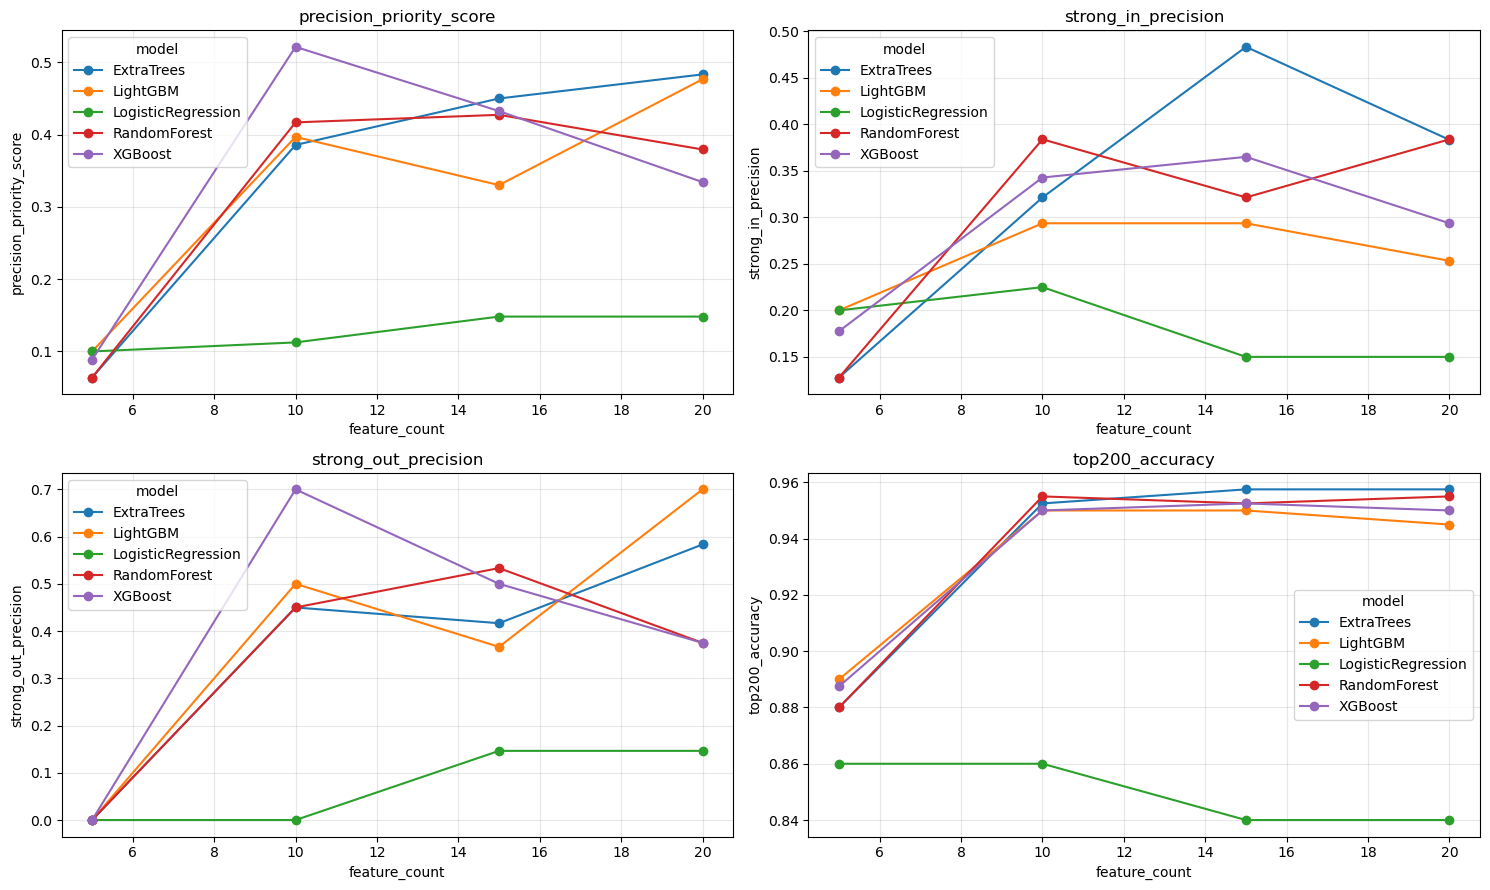

In [411]:
fig, axes = plt.subplots(2, 2, figsize=(15, 9))
axes = axes.ravel()

for metric, ax in zip(
    ["precision_priority_score", "strong_in_precision", "strong_out_precision", "top200_accuracy"],
    axes,
):
    pivot_df = coarse_model_summary_df.pivot(index="feature_count", columns="model", values=metric)
    pivot_df.plot(marker="o", ax=ax)
    ax.set_title(metric)
    ax.grid(alpha=0.3)
    ax.set_xlabel("feature_count")
    ax.set_ylabel(metric)

plt.tight_layout()
plt.show()


## 28. feature 개수 세부 탐색

아래 셀에서 `fine_search_range`를 직접 바꾸면,
예를 들어 `5`와 `10`이 비슷할 때 `5~10`만 다시 촘촘하게 돌릴 수 있습니다.


In [412]:
fine_search_range = None
# 예시:
# fine_search_range = list(range(5, 11))
# fine_search_range = list(range(10, 16))


In [413]:
fine_model_summary_df = pd.DataFrame()

if fine_search_range:
    valid_counts = [count for count in fine_search_range if 1 <= count <= len(ranked_feature_list)]
    fine_frames = []
    for feature_count in valid_counts:
        selected_features = ranked_feature_list[:feature_count]
        for model_name, model in model_candidates.items():
            result_df = fit_and_score_model(
                model_name=model_name,
                model=model,
                feature_list=selected_features,
                train_df=train_snapshot_df,
                test_df=test_snapshot_df,
                periods=test_periods,
            )
            fine_frames.append(result_df)

    fine_results_df = pd.concat(fine_frames, ignore_index=True)
    fine_results_df["precision_priority_score"] = (
        fine_results_df["strong_in_precision"] + fine_results_df["strong_out_precision"]
    ) / 2.0

    fine_model_summary_df = (
        fine_results_df.groupby(["model", "feature_count"])[
            [
                "precision_priority_score",
                "strong_in_precision",
                "strong_out_precision",
                "top200_accuracy",
                "top100_member_precision",
                "top200_member_precision",
                "actual_member_avg_pred_rank",
            ]
        ]
        .mean()
        .reset_index()
        .sort_values(
            [
                "precision_priority_score",
                "top200_accuracy",
                "top100_member_precision",
                "actual_member_avg_pred_rank",
            ],
            ascending=[False, False, False, True],
        )
    )

fine_model_summary_df


""


## 29. 최종 선정 규칙 요약

In [414]:
selection_rule_df = pd.DataFrame(
    [
        {
            "priority": 1,
            "criterion": "strong_in_precision, strong_out_precision",
            "how_to_compare": "평균값인 precision_priority_score를 먼저 본다",
        },
        {
            "priority": 2,
            "criterion": "top200_accuracy",
            "how_to_compare": "precision이 비슷하면 top200 정확도가 높은 조합 우선",
        },
        {
            "priority": 3,
            "criterion": "rank 품질",
            "how_to_compare": "top100/top200 member precision이 높고 actual_member_avg_pred_rank가 낮은 조합 우선",
        },
        {
            "priority": 4,
            "criterion": "feature_count",
            "how_to_compare": "성능이 비슷하면 더 적은 피처를 우선",
        },
    ]
)
selection_rule_df


,priority,criterion,how_to_compare
0,1,"strong_in_precision, strong_out_precision",평균값인 precision_priority_score를 먼저 본다
1,2,top200_accuracy,precision이 비슷하면 top200 정확도가 높은 조합 우선
2,3,rank 품질,top100/top200 member precision이 높고 actual_member_avg_pred_rank가 낮은 조합 우선
3,4,feature_count,성능이 비슷하면 더 적은 피처를 우선


## 30. XGBoost 집중 탐색: 5개~15개 피처

여기서는 `XGBoost`만 따로 떼서 `5~15개` 피처를 모두 비교합니다.

목표는 아래 두 가지입니다.

- `몇 개 피처`일 때 성능이 가장 좋은지 확인
- 그때 `실제로 선택된 피처 목록`이 무엇인지 확인


In [415]:
focused_model_candidates = {
    model_name: model_candidates[model_name]
    for model_name in ["XGBoost", "LightGBM", "ExtraTrees"]
    if model_name in model_candidates
}

focused_model_candidates.keys()


dict_keys(['XGBoost', 'LightGBM', 'ExtraTrees'])

In [416]:
xgb_feature_count_range = list(range(5, min(15, len(ranked_feature_list)) + 1))
xgb_feature_count_range


[5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]

In [417]:
xgb_fine_frames = []

for feature_count in xgb_feature_count_range:
    selected_features = ranked_feature_list[:feature_count]
    result_df = fit_and_score_model(
        model_name="XGBoost",
        model=model_candidates["XGBoost"],
        feature_list=selected_features,
        train_df=train_snapshot_df,
        test_df=test_snapshot_df,
        periods=test_periods,
    )
    xgb_fine_frames.append(result_df)

xgb_fine_results_df = pd.concat(xgb_fine_frames, ignore_index=True)
xgb_fine_results_df["precision_priority_score"] = (
    xgb_fine_results_df["strong_in_precision"] + xgb_fine_results_df["strong_out_precision"]
) / 2.0

xgb_fine_results_df


,top200_accuracy,strong_in_precision,strong_out_precision,actual_member_avg_pred_rank,actual_in_avg_pred_rank,actual_out_avg_pred_rank,top100_member_precision,top200_member_precision,period,model,feature_count,feature_list,precision_priority_score
0,0.890,0.105263,0.000000,107.250000,214.333333,191.285714,1.00,0.890,2025_H1,XGBoost,5,"period_rank, foreign_change, sector_rank, major_holder_ratio, sector_relative_rank",0.052632
1,0.885,0.250000,0.000000,107.828283,163.714286,185.833333,0.97,0.885,2025_H2,XGBoost,5,"period_rank, foreign_change, sector_rank, major_holder_ratio, sector_relative_rank",0.125000
2,0.895,0.111111,0.000000,107.055000,222.222222,190.428571,0.99,0.895,2025_H1,XGBoost,6,"period_rank, foreign_change, sector_rank, major_holder_ratio, sector_relative_rank, rank_change",0.055556
3,0.880,0.150000,0.000000,106.848485,167.285714,182.000000,0.98,0.880,2025_H2,XGBoost,6,"period_rank, foreign_change, sector_rank, major_holder_ratio, sector_relative_rank, rank_change",0.075000
4,0.905,0.066667,0.000000,106.640000,224.111111,183.714286,1.00,0.905,2025_H1,XGBoost,7,"period_rank, foreign_change, sector_rank, major_holder_ratio, sector_relative_rank, rank_change, treasury_ratio",0.033333
5,0.885,0.250000,0.100000,106.787879,168.142857,177.833333,0.98,0.885,2025_H2,XGBoost,7,"period_rank, foreign_change, sector_rank, major_holder_ratio, sector_relative_rank, rank_change, treasury_ratio",0.175000
6,0.905,0.125000,0.000000,106.605000,223.555556,182.857143,0.99,0.905,2025_H1,XGBoost,8,"period_rank, foreign_change, sector_rank, major_holder_ratio, sector_relative_rank, rank_change, treasury_ratio, turnover_ratio",0.062500
7,0.895,0.250000,0.000000,106.893939,174.714286,179.333333,0.98,0.895,2025_H2,XGBoost,8,"period_rank, foreign_change, sector_rank, major_holder_ratio, sector_relative_rank, rank_change, treasury_ratio, turnover_ratio",0.125000
8,0.950,0.285714,1.000000,104.115000,229.333333,156.428571,0.99,0.950,2025_H1,XGBoost,9,"period_rank, foreign_change, sector_rank, major_holder_ratio, sector_relative_rank, rank_change, treasury_ratio, turnover_ratio, prev_was_member",0.642857
9,0.950,0.400000,0.333333,102.616162,210.142857,141.333333,0.98,0.950,2025_H2,XGBoost,9,"period_rank, foreign_change, sector_rank, major_holder_ratio, sector_relative_rank, rank_change, treasury_ratio, turnover_ratio, prev_was_member",0.366667


In [418]:
xgb_fine_summary_df = (
    xgb_fine_results_df.groupby("feature_count")[
        [
            "precision_priority_score",
            "strong_in_precision",
            "strong_out_precision",
            "top200_accuracy",
            "top100_member_precision",
            "top200_member_precision",
            "actual_member_avg_pred_rank",
            "actual_in_avg_pred_rank",
            "actual_out_avg_pred_rank",
        ]
    ]
    .mean()
    .reset_index()
    .sort_values(
        [
            "precision_priority_score",
            "top200_accuracy",
            "top100_member_precision",
            "actual_member_avg_pred_rank",
        ],
        ascending=[False, False, False, True],
    )
)
xgb_fine_summary_df


,feature_count,precision_priority_score,strong_in_precision,strong_out_precision,top200_accuracy,top100_member_precision,top200_member_precision,actual_member_avg_pred_rank,actual_in_avg_pred_rank,actual_out_avg_pred_rank
6,11,0.588095,0.342857,0.833333,0.9500,0.980,0.9500,103.678687,220.261905,141.238095
5,10,0.521429,0.342857,0.700000,0.9500,0.985,0.9500,103.354495,219.761905,148.357143
8,13,0.510714,0.271429,0.750000,0.9475,0.985,0.9475,103.505253,222.111111,148.011905
4,9,0.504762,0.342857,0.666667,0.9500,0.985,0.9500,103.365581,219.738095,148.880952
7,12,0.476623,0.253247,0.700000,0.9450,0.985,0.9450,103.550682,220.706349,145.440476
10,15,0.432540,0.365079,0.500000,0.9525,0.985,0.9525,103.340152,219.992063,143.321429
9,14,0.219048,0.271429,0.166667,0.9475,0.985,0.9475,103.522172,221.436508,146.250000
2,7,0.104167,0.158333,0.050000,0.8950,0.990,0.8950,106.713939,196.126984,180.773810
3,8,0.093750,0.187500,0.000000,0.9000,0.985,0.9000,106.749470,199.134921,181.095238
0,5,0.088816,0.177632,0.000000,0.8875,0.985,0.8875,107.539141,189.023810,188.559524


In [419]:
xgb_best_feature_count = int(xgb_fine_summary_df.iloc[0]["feature_count"])
xgb_best_features = ranked_feature_list[:xgb_best_feature_count]

xgb_best_feature_df = pd.DataFrame(
    {
        "rank": list(range(1, len(xgb_best_features) + 1)),
        "feature": xgb_best_features,
        "source": [
            "core" if feature in v1_core_features else "candidate"
            for feature in xgb_best_features
        ],
    }
)

print("best_xgb_feature_count:", xgb_best_feature_count)
xgb_best_feature_df


best_xgb_feature_count: 11


,rank,feature,source
0,1,period_rank,core
1,2,foreign_change,core
2,3,sector_rank,core
3,4,major_holder_ratio,core
4,5,sector_relative_rank,core
5,6,rank_change,candidate
6,7,treasury_ratio,core
7,8,turnover_ratio,core
8,9,prev_was_member,candidate
9,10,avg_mktcap,candidate


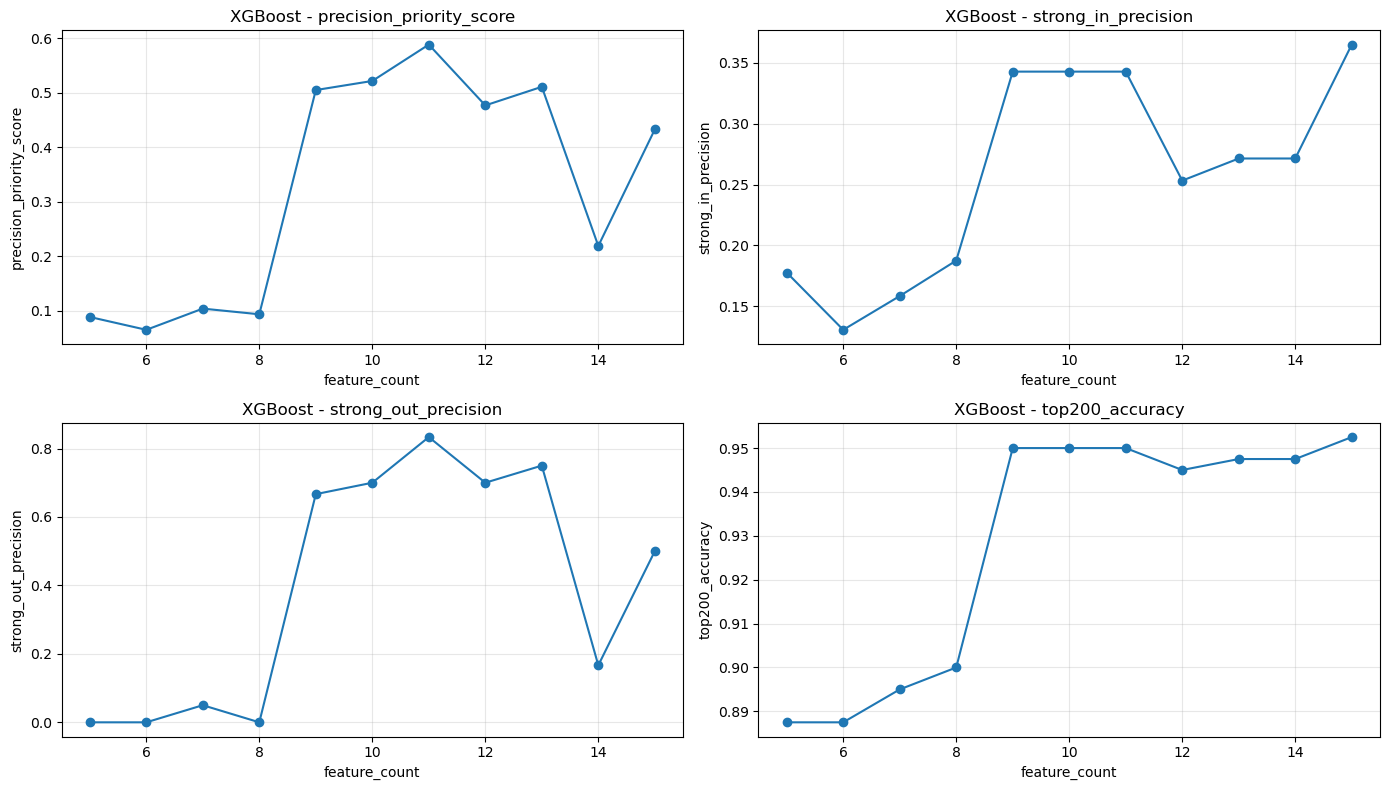

In [420]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.ravel()

for metric, ax in zip(
    ["precision_priority_score", "strong_in_precision", "strong_out_precision", "top200_accuracy"],
    axes,
):
    xgb_fine_summary_df.sort_values("feature_count").plot(
        x="feature_count",
        y=metric,
        marker="o",
        ax=ax,
        legend=False,
    )
    ax.set_title(f"XGBoost - {metric}")
    ax.grid(alpha=0.3)
    ax.set_xlabel("feature_count")
    ax.set_ylabel(metric)

plt.tight_layout()
plt.show()


## 31. 최종 3개 모델 집중 비교

여기서는 `XGBoost`, `LightGBM`, `ExtraTrees`만 놓고,
각 모델의 가장 유리한 피처 개수 구간을 비교합니다.

현재는 coarse search 결과를 기준으로 비교하지만,
필요하면 `LightGBM`, `ExtraTrees`도 이후에 `5~15` 세부 탐색으로 확장할 수 있습니다.


In [421]:
focused_compare_df = coarse_model_summary_df[
    coarse_model_summary_df["model"].isin(["XGBoost", "LightGBM", "ExtraTrees"])
].copy()

focused_compare_df


,model,feature_count,precision_priority_score,strong_in_precision,strong_out_precision,top200_accuracy,top100_member_precision,top200_member_precision,actual_member_avg_pred_rank,actual_in_avg_pred_rank,actual_out_avg_pred_rank
17,XGBoost,10,0.521429,0.342857,0.700000,0.9500,0.985,0.9500,103.354495,219.761905,148.357143
3,ExtraTrees,20,0.483333,0.383333,0.583333,0.9575,0.990,0.9575,102.567677,224.793651,159.535714
7,LightGBM,20,0.476623,0.253247,0.700000,0.9450,0.980,0.9450,103.656742,225.571429,147.916667
2,ExtraTrees,15,0.450000,0.483333,0.416667,0.9575,0.990,0.9575,102.635808,222.619048,155.440476
18,XGBoost,15,0.432540,0.365079,0.500000,0.9525,0.985,0.9525,103.340152,219.992063,143.321429
5,LightGBM,10,0.396825,0.293651,0.500000,0.9500,0.980,0.9500,103.331061,220.595238,156.190476
1,ExtraTrees,10,0.385714,0.321429,0.450000,0.9525,0.985,0.9525,102.871136,222.301587,151.428571
19,XGBoost,20,0.334325,0.293651,0.375000,0.9500,0.975,0.9500,103.510631,221.341270,139.404762
6,LightGBM,15,0.330159,0.293651,0.366667,0.9500,0.990,0.9500,103.148258,224.833333,158.261905
4,LightGBM,5,0.100000,0.200000,0.000000,0.8900,0.985,0.8900,107.533081,187.079365,182.142857


In [422]:
focused_best_by_model_df = (
    focused_compare_df.sort_values(
        [
            "precision_priority_score",
            "top200_accuracy",
            "top100_member_precision",
            "actual_member_avg_pred_rank",
        ],
        ascending=[False, False, False, True],
    )
    .groupby("model", as_index=False)
    .head(1)
    .reset_index(drop=True)
)

focused_best_by_model_df


,model,feature_count,precision_priority_score,strong_in_precision,strong_out_precision,top200_accuracy,top100_member_precision,top200_member_precision,actual_member_avg_pred_rank,actual_in_avg_pred_rank,actual_out_avg_pred_rank
0,XGBoost,10,0.521429,0.342857,0.700000,0.9500,0.985,0.9500,103.354495,219.761905,148.357143
1,ExtraTrees,20,0.483333,0.383333,0.583333,0.9575,0.990,0.9575,102.567677,224.793651,159.535714
2,LightGBM,20,0.476623,0.253247,0.700000,0.9450,0.980,0.9450,103.656742,225.571429,147.916667


In [423]:
focused_best_feature_map = {}
for _, row in focused_best_by_model_df.iterrows():
    model_name = row["model"]
    feature_count = int(row["feature_count"])
    focused_best_feature_map[model_name] = ranked_feature_list[:feature_count]

focused_best_feature_rows = []
for model_name, features in focused_best_feature_map.items():
    for rank, feature in enumerate(features, start=1):
        focused_best_feature_rows.append(
            {
                "model": model_name,
                "feature_count": len(features),
                "rank": rank,
                "feature": feature,
                "source": "core" if feature in v1_core_features else "candidate",
            }
        )

focused_best_feature_detail_df = pd.DataFrame(focused_best_feature_rows)
focused_best_feature_detail_df


,model,feature_count,rank,feature,source
0,XGBoost,10,1,period_rank,core
1,XGBoost,10,2,foreign_change,core
2,XGBoost,10,3,sector_rank,core
3,XGBoost,10,4,major_holder_ratio,core
4,XGBoost,10,5,sector_relative_rank,core
5,XGBoost,10,6,rank_change,candidate
6,XGBoost,10,7,treasury_ratio,core
7,XGBoost,10,8,turnover_ratio,core
8,XGBoost,10,9,prev_was_member,candidate
9,XGBoost,10,10,avg_mktcap,candidate


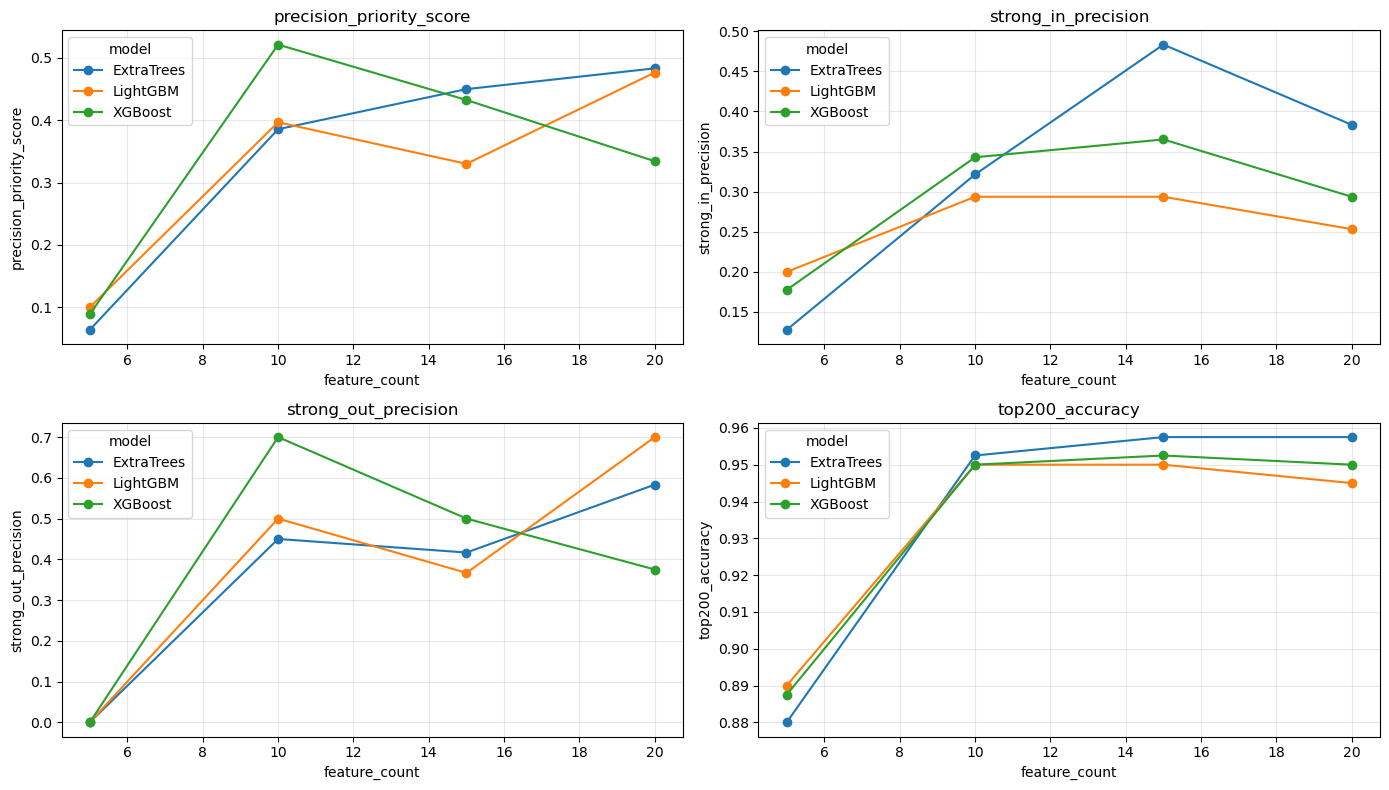

In [424]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.ravel()

for metric, ax in zip(
    ["precision_priority_score", "strong_in_precision", "strong_out_precision", "top200_accuracy"],
    axes,
):
    plot_df = focused_compare_df.pivot(index="feature_count", columns="model", values=metric)
    plot_df.plot(marker="o", ax=ax)
    ax.set_title(metric)
    ax.grid(alpha=0.3)
    ax.set_xlabel("feature_count")
    ax.set_ylabel(metric)

plt.tight_layout()
plt.show()


## 32. 현재 기준 최적 모델 요약

In [425]:
focused_final_ranking_df = focused_best_by_model_df.sort_values(
    [
        "precision_priority_score",
        "top200_accuracy",
        "top100_member_precision",
        "actual_member_avg_pred_rank",
    ],
    ascending=[False, False, False, True],
).reset_index(drop=True)

focused_final_ranking_df


,model,feature_count,precision_priority_score,strong_in_precision,strong_out_precision,top200_accuracy,top100_member_precision,top200_member_precision,actual_member_avg_pred_rank,actual_in_avg_pred_rank,actual_out_avg_pred_rank
0,XGBoost,10,0.521429,0.342857,0.700000,0.9500,0.985,0.9500,103.354495,219.761905,148.357143
1,ExtraTrees,20,0.483333,0.383333,0.583333,0.9575,0.990,0.9575,102.567677,224.793651,159.535714
2,LightGBM,20,0.476623,0.253247,0.700000,0.9450,0.980,0.9450,103.656742,225.571429,147.916667


## 33. v1 vs v1.5 최종 후보 직접 비교

이제 현재 기준 최적 후보인 `v1.5 = XGBoost + 11개 피처`와
기존 `v1 = LightGBM + core 10개 피처`를 직접 비교합니다.

비교 우선순위는 동일합니다.

1. `strong_in_precision`, `strong_out_precision`
2. `top200_accuracy`
3. `rank 품질`


In [426]:
v1_feature_list = list(pkg.get("features", []))

if "xgb_best_feature_count" not in globals():
    raise RuntimeError("먼저 XGBoost 집중 탐색 셀을 실행해서 xgb_best_feature_count를 만들어야 합니다.")

v1_5_best_feature_list = ranked_feature_list[:xgb_best_feature_count]

comparison_feature_sets_df = pd.DataFrame(
    [
        {
            "version": "v1",
            "model": "LightGBM",
            "feature_count": len(v1_feature_list),
            "feature_list": ", ".join(v1_feature_list),
        },
        {
            "version": "v1.5_best",
            "model": "XGBoost",
            "feature_count": len(v1_5_best_feature_list),
            "feature_list": ", ".join(v1_5_best_feature_list),
        },
    ]
)
comparison_feature_sets_df


,version,model,feature_count,feature_list
0,v1,LightGBM,10,"period_rank, treasury_ratio, sector_relative_rank, prev_rank, major_holder_ratio, sector_rank, foreign_change, turnover_ratio, sector_member_score, float_mktcap"
1,v1.5_best,XGBoost,11,"period_rank, foreign_change, sector_rank, major_holder_ratio, sector_relative_rank, rank_change, treasury_ratio, turnover_ratio, prev_was_member, avg_mktcap, last_foreign_ratio"


In [427]:
final_compare_frames = []

final_model_map = {
    "v1": (
        "LightGBM",
        LGBMClassifier(
            n_estimators=300,
            learning_rate=0.05,
            num_leaves=31,
            random_state=42,
            class_weight="balanced",
            verbosity=-1,
        ),
        v1_feature_list,
    ),
    "v1.5_best": (
        "XGBoost",
        XGBClassifier(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=6,
            subsample=0.9,
            colsample_bytree=0.9,
            random_state=42,
            eval_metric="logloss",
            n_jobs=1,
        ),
        v1_5_best_feature_list,
    ),
}

for version_name, (model_name, model, feature_list) in final_model_map.items():
    result_df = fit_and_score_model(
        model_name=model_name,
        model=model,
        feature_list=feature_list,
        train_df=train_snapshot_df,
        test_df=test_snapshot_df,
        periods=test_periods,
    )
    result_df["version"] = version_name
    final_compare_frames.append(result_df)

v1_vs_v1_5_period_df = pd.concat(final_compare_frames, ignore_index=True)
v1_vs_v1_5_period_df["precision_priority_score"] = (
    v1_vs_v1_5_period_df["strong_in_precision"] + v1_vs_v1_5_period_df["strong_out_precision"]
) / 2.0

v1_vs_v1_5_period_df


,top200_accuracy,strong_in_precision,strong_out_precision,actual_member_avg_pred_rank,actual_in_avg_pred_rank,actual_out_avg_pred_rank,top100_member_precision,top200_member_precision,period,model,feature_count,feature_list,version,precision_priority_score
0,0.915,0.142857,0.000000,105.690000,223.888889,178.000000,0.99,0.915,2025_H1,LightGBM,10,"period_rank, treasury_ratio, sector_relative_rank, prev_rank, major_holder_ratio, sector_rank, foreign_change, turnover_ratio, sector_member_score, float_mktcap",v1,0.071429
1,0.900,0.200000,0.166667,106.070707,177.714286,181.666667,0.99,0.900,2025_H2,LightGBM,10,"period_rank, treasury_ratio, sector_relative_rank, prev_rank, major_holder_ratio, sector_rank, foreign_change, turnover_ratio, sector_member_score, float_mktcap",v1,0.183333
2,0.950,0.285714,1.000000,104.620000,230.666667,143.142857,0.98,0.950,2025_H1,XGBoost,11,"period_rank, foreign_change, sector_rank, major_holder_ratio, sector_relative_rank, rank_change, treasury_ratio, turnover_ratio, prev_was_member, avg_mktcap, last_foreign_ratio",v1.5_best,0.642857
3,0.950,0.400000,0.666667,102.737374,209.857143,139.333333,0.98,0.950,2025_H2,XGBoost,11,"period_rank, foreign_change, sector_rank, major_holder_ratio, sector_relative_rank, rank_change, treasury_ratio, turnover_ratio, prev_was_member, avg_mktcap, last_foreign_ratio",v1.5_best,0.533333


In [428]:
v1_vs_v1_5_summary_df = (
    v1_vs_v1_5_period_df.groupby(["version", "model"])[
        [
            "precision_priority_score",
            "strong_in_precision",
            "strong_out_precision",
            "top200_accuracy",
            "top100_member_precision",
            "top200_member_precision",
            "actual_member_avg_pred_rank",
            "actual_in_avg_pred_rank",
            "actual_out_avg_pred_rank",
        ]
    ]
    .mean()
    .reset_index()
    .sort_values(
        [
            "precision_priority_score",
            "top200_accuracy",
            "top100_member_precision",
            "actual_member_avg_pred_rank",
        ],
        ascending=[False, False, False, True],
    )
)
v1_vs_v1_5_summary_df


,version,model,precision_priority_score,strong_in_precision,strong_out_precision,top200_accuracy,top100_member_precision,top200_member_precision,actual_member_avg_pred_rank,actual_in_avg_pred_rank,actual_out_avg_pred_rank
1,v1.5_best,XGBoost,0.588095,0.342857,0.833333,0.9500,0.98,0.9500,103.678687,220.261905,141.238095
0,v1,LightGBM,0.127381,0.171429,0.083333,0.9075,0.99,0.9075,105.880354,200.801587,179.833333


In [429]:
v1_vs_v1_5_delta_df = v1_vs_v1_5_summary_df.set_index("version").copy()

if {"v1", "v1.5_best"}.issubset(v1_vs_v1_5_delta_df.index):
    delta_row = (
        v1_vs_v1_5_delta_df.loc["v1.5_best"][
            [
                "precision_priority_score",
                "strong_in_precision",
                "strong_out_precision",
                "top200_accuracy",
                "top100_member_precision",
                "top200_member_precision",
                "actual_member_avg_pred_rank",
                "actual_in_avg_pred_rank",
                "actual_out_avg_pred_rank",
            ]
        ]
        - v1_vs_v1_5_delta_df.loc["v1"][
            [
                "precision_priority_score",
                "strong_in_precision",
                "strong_out_precision",
                "top200_accuracy",
                "top100_member_precision",
                "top200_member_precision",
                "actual_member_avg_pred_rank",
                "actual_in_avg_pred_rank",
                "actual_out_avg_pred_rank",
            ]
        ]
    )
    v1_vs_v1_5_delta_view_df = delta_row.to_frame("v1.5_minus_v1").reset_index().rename(columns={"index": "metric"})
else:
    v1_vs_v1_5_delta_view_df = pd.DataFrame()

v1_vs_v1_5_delta_view_df


,metric,v1.5_minus_v1
0,precision_priority_score,0.460714
1,strong_in_precision,0.171429
2,strong_out_precision,0.75
3,top200_accuracy,0.0425
4,top100_member_precision,-0.01
5,top200_member_precision,0.0425
6,actual_member_avg_pred_rank,-2.201667
7,actual_in_avg_pred_rank,19.460317
8,actual_out_avg_pred_rank,-38.595238


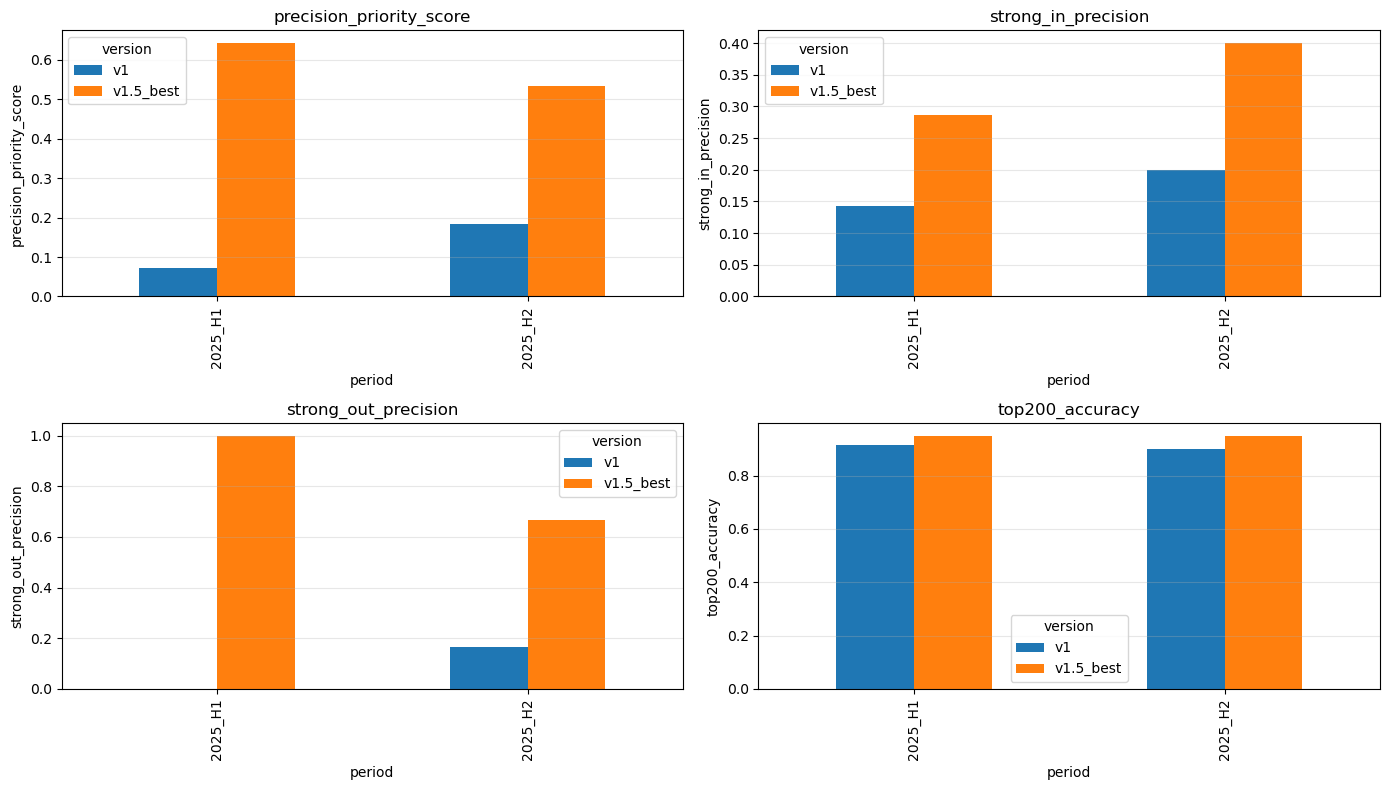

In [430]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.ravel()

for metric, ax in zip(
    ["precision_priority_score", "strong_in_precision", "strong_out_precision", "top200_accuracy"],
    axes,
):
    plot_df = v1_vs_v1_5_period_df.pivot(index="period", columns="version", values=metric)
    plot_df.plot(kind="bar", ax=ax)
    ax.set_title(metric)
    ax.grid(axis="y", alpha=0.3)
    ax.set_xlabel("period")
    ax.set_ylabel(metric)

plt.tight_layout()
plt.show()


## 34. v1 대비 v1.5 최종 해석 메모

In [431]:
v1_vs_v1_5_note_df = pd.DataFrame(
    [
        {
            "question": "precision 기준으로 누가 우세한가?",
            "how_to_read": "precision_priority_score, strong_in_precision, strong_out_precision을 먼저 본다",
        },
        {
            "question": "top200 멤버 예측도 좋아졌는가?",
            "how_to_read": "top200_accuracy, top100/top200_member_precision을 본다",
        },
        {
            "question": "순위 품질은 어떤가?",
            "how_to_read": "actual_member_avg_pred_rank와 actual_out_avg_pred_rank가 낮을수록 좋다",
        },
        {
            "question": "최종 채택 기준은?",
            "how_to_read": "우선순위는 precision > top200_accuracy > rank 품질",
        },
    ]
)
v1_vs_v1_5_note_df


,question,how_to_read
0,precision 기준으로 누가 우세한가?,"precision_priority_score, strong_in_precision, strong_out_precision을 먼저 본다"
1,top200 멤버 예측도 좋아졌는가?,"top200_accuracy, top100/top200_member_precision을 본다"
2,순위 품질은 어떤가?,actual_member_avg_pred_rank와 actual_out_avg_pred_rank가 낮을수록 좋다
3,최종 채택 기준은?,우선순위는 precision > top200_accuracy > rank 품질


## 35. 2020_H1 ~ 2025_H2 전체 기간 시각 비교

여기서는 `v1`과 `v1.5_best`를 전체 기간에 대해 시각적으로 비교합니다.

주의:
- 이 비교는 `2025_H1`, `2025_H2` 테스트 구간뿐 아니라 과거 기간도 함께 포함합니다.
- 따라서 `train 구간 포함 전체 흐름 시각화`로 해석하는 것이 맞습니다.
- 최종 일반화 성능 판단은 여전히 `test period` 결과를 우선합니다.


In [432]:
full_period_order = [period for period in historical_period_order if period != "2026_H1"]
full_period_order


['2020_H1',
 '2020_H2',
 '2021_H1',
 '2021_H2',
 '2022_H1',
 '2022_H2',
 '2023_H1',
 '2023_H2',
 '2024_H1',
 '2024_H2',
 '2025_H1',
 '2025_H2']

In [433]:
def score_full_periods(version_name: str, model_name: str, model, feature_list: list[str]) -> pd.DataFrame:
    X_train = train_snapshot_df[feature_list].fillna(0.0)
    y_train = train_snapshot_df["is_member"].fillna(0).astype(int)
    model.fit(X_train, y_train)

    rows = []
    for period in full_period_order:
        period_frame = historical_snapshot_df[historical_snapshot_df["period"] == period].copy()
        if period_frame.empty:
            continue

        X_period = period_frame[feature_list].fillna(0.0)
        if hasattr(model, "predict_proba"):
            scores = model.predict_proba(X_period)[:, 1]
        else:
            scores = model.decision_function(X_period)

        period_frame["score"] = scores
        period_frame["pred_rank"] = period_frame["score"].rank(ascending=False, method="first")

        metric_row = evaluate_period_scores(period_frame)
        metric_row["period"] = period
        metric_row["version"] = version_name
        metric_row["model"] = model_name
        metric_row["feature_count"] = len(feature_list)
        rows.append(metric_row)

    return pd.DataFrame(rows)


In [434]:
full_period_compare_frames = []

full_period_model_map = {
    "v1": (
        "LightGBM",
        LGBMClassifier(
            n_estimators=300,
            learning_rate=0.05,
            num_leaves=31,
            random_state=42,
            class_weight="balanced",
            verbosity=-1,
        ),
        v1_feature_list,
    ),
    "v1.5_best": (
        "XGBoost",
        XGBClassifier(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=6,
            subsample=0.9,
            colsample_bytree=0.9,
            random_state=42,
            eval_metric="logloss",
            n_jobs=1,
        ),
        v1_5_best_feature_list,
    ),
}

for version_name, (model_name, model, feature_list) in full_period_model_map.items():
    version_df = score_full_periods(version_name, model_name, model, feature_list)
    full_period_compare_frames.append(version_df)

full_period_compare_df = pd.concat(full_period_compare_frames, ignore_index=True)
full_period_compare_df["precision_priority_score"] = (
    full_period_compare_df["strong_in_precision"] + full_period_compare_df["strong_out_precision"]
) / 2.0

full_period_compare_df


,top200_accuracy,strong_in_precision,strong_out_precision,actual_member_avg_pred_rank,actual_in_avg_pred_rank,actual_out_avg_pred_rank,top100_member_precision,top200_member_precision,period,version,model,feature_count,precision_priority_score
0,0.900,0.300000,0.125000,106.505000,171.636364,248.142857,1.00,0.900,2020_H1,v1,LightGBM,10,0.212500
1,0.990,0.818182,1.000000,99.500000,156.777778,242.333333,1.00,0.990,2020_H2,v1,LightGBM,10,0.909091
2,0.980,0.571429,0.000000,98.500000,177.250000,229.500000,1.00,0.980,2021_H1,v1,LightGBM,10,0.285714
3,0.965,0.333333,1.000000,97.000000,148.000000,222.428571,1.00,0.965,2021_H2,v1,LightGBM,10,0.666667
4,0.985,0.875000,1.000000,99.000000,142.714286,222.500000,1.00,0.985,2022_H1,v1,LightGBM,10,0.937500
5,1.000,1.000000,0.000000,100.500000,195.000000,249.000000,1.00,1.000,2022_H2,v1,LightGBM,10,0.500000
6,1.000,1.000000,1.000000,100.500000,168.600000,215.400000,1.00,1.000,2023_H1,v1,LightGBM,10,1.000000
7,0.995,0.888889,1.000000,100.000000,162.250000,228.750000,1.00,0.995,2023_H2,v1,LightGBM,10,0.944444
8,0.985,0.833333,1.000000,99.000000,136.000000,215.857143,1.00,0.985,2024_H1,v1,LightGBM,10,0.916667
9,0.995,0.800000,1.000000,100.000000,163.750000,232.200000,1.00,0.995,2024_H2,v1,LightGBM,10,0.900000


In [435]:
full_period_summary_df = (
    full_period_compare_df.groupby(["version", "model"])[
        [
            "precision_priority_score",
            "strong_in_precision",
            "strong_out_precision",
            "top200_accuracy",
            "top100_member_precision",
            "top200_member_precision",
            "actual_member_avg_pred_rank",
            "actual_in_avg_pred_rank",
            "actual_out_avg_pred_rank",
        ]
    ]
    .mean()
    .reset_index()
    .sort_values(
        [
            "precision_priority_score",
            "top200_accuracy",
            "top100_member_precision",
            "actual_member_avg_pred_rank",
        ],
        ascending=[False, False, False, True],
    )
)
full_period_summary_df


,version,model,precision_priority_score,strong_in_precision,strong_out_precision,top200_accuracy,top100_member_precision,top200_member_precision,actual_member_avg_pred_rank,actual_in_avg_pred_rank,actual_out_avg_pred_rank
1,v1.5_best,XGBoost,0.845112,0.759668,0.930556,0.978333,0.995833,0.978333,100.288531,199.248025,195.419444
0,v1,LightGBM,0.627279,0.646919,0.607639,0.967500,0.998333,0.967500,101.022142,168.631800,222.148214


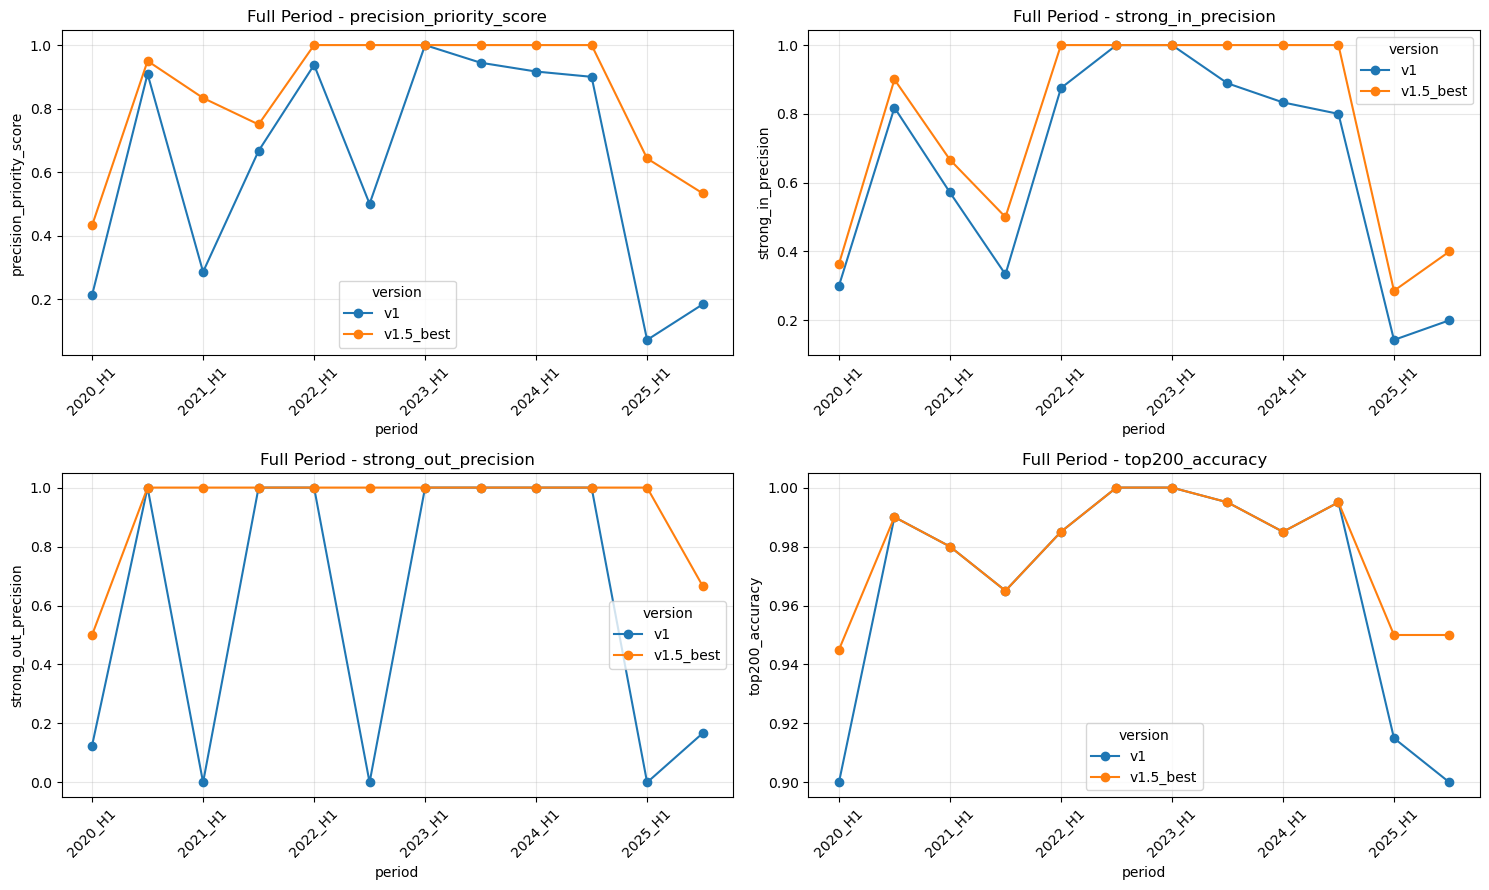

In [436]:
fig, axes = plt.subplots(2, 2, figsize=(15, 9))
axes = axes.ravel()

for metric, ax in zip(
    ["precision_priority_score", "strong_in_precision", "strong_out_precision", "top200_accuracy"],
    axes,
):
    plot_df = full_period_compare_df.pivot(index="period", columns="version", values=metric)
    plot_df = plot_df.reindex(full_period_order)
    plot_df.plot(marker="o", ax=ax)
    ax.set_title(f"Full Period - {metric}")
    ax.grid(alpha=0.3)
    ax.set_xlabel("period")
    ax.set_ylabel(metric)
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()


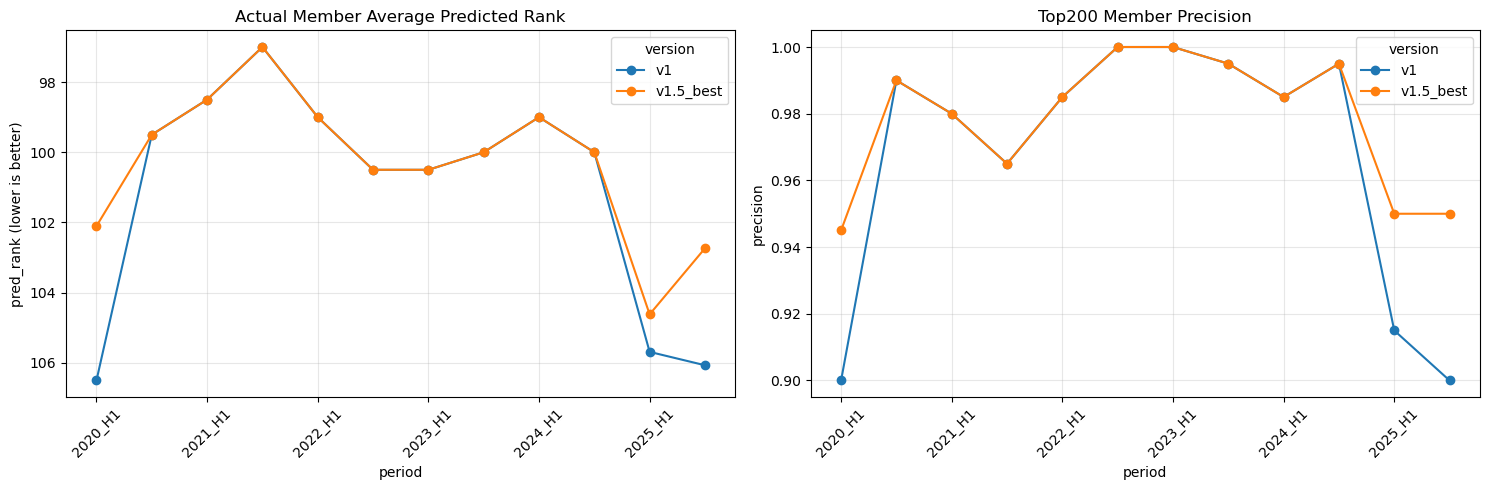

In [437]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

rank_plot_df = full_period_compare_df.pivot(index="period", columns="version", values="actual_member_avg_pred_rank")
rank_plot_df = rank_plot_df.reindex(full_period_order)
rank_plot_df.plot(marker="o", ax=axes[0])
axes[0].invert_yaxis()
axes[0].set_title("Actual Member Average Predicted Rank")
axes[0].set_ylabel("pred_rank (lower is better)")
axes[0].grid(alpha=0.3)
axes[0].tick_params(axis="x", rotation=45)

top200_plot_df = full_period_compare_df.pivot(index="period", columns="version", values="top200_member_precision")
top200_plot_df = top200_plot_df.reindex(full_period_order)
top200_plot_df.plot(marker="o", ax=axes[1])
axes[1].set_title("Top200 Member Precision")
axes[1].set_ylabel("precision")
axes[1].grid(alpha=0.3)
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()


In [438]:
train_test_tag_df = pd.DataFrame(
    {
        "period": full_period_order,
        "split_type": [
            "train" if period in train_periods else "test" if period in test_periods else "other"
            for period in full_period_order
        ],
    }
)
train_test_tag_df


,period,split_type
0,2020_H1,other
1,2020_H2,train
2,2021_H1,train
3,2021_H2,train
4,2022_H1,train
5,2022_H2,train
6,2023_H1,train
7,2023_H2,train
8,2024_H1,train
9,2024_H2,train


## 36. 지금까지 결과 기준 다음 할 일

현재 노트북 기준으로 다음 액션은 이렇게 정리할 수 있습니다.

1. `v1.5_best = XGBoost + 11개 피처`를 현재 최종 후보로 확정
2. `snapshot_version = v1_5_xgb_11` 같은 이름으로 SQL snapshot 관리 체계 반영
3. 필요하면 `XGBoost 10~12개` 주변 하이퍼파라미터까지 미세 조정
4. README는 발표용이 아니라 개인 포트폴리오 톤으로 재정리
